# 2.0 Entendimiento de los datos — Saber Pro Genéricas 2024

Este notebook explora el archivo `Examen_Saber_Pro_Genericas_2024.txt` para conocer su tamaño, estructura, calidad, distribuciones y relaciones.

> **Alcance:** este es únicamente un análisis exploratorio. No se rellenan datos faltantes, no se eliminan valores atípicos, no se transforman variables y no se entrenan modelos.

In [ ]:
# Librerías
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Configuración visual
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams['figure.dpi'] = 110

RANDOM_STATE = 42
PLOT_SAMPLE_SIZE = 60_000

## 1. Carga y validación inicial

Primero se localiza y carga el archivo. Después se revisan sus dimensiones, consumo de memoria y posibles duplicados.

In [ ]:
# La ruta funciona desde la raíz del proyecto y desde notebooks/
path_from_root = Path('data/raw/Examen_Saber_Pro_Genericas_2024.txt')
path_from_notebooks = Path('../data/raw/Examen_Saber_Pro_Genericas_2024.txt')

if path_from_root.exists():
    data_path = path_from_root
else:
    data_path = path_from_notebooks

print('Archivo:', data_path.resolve())
print(f'Tamaño: {data_path.stat().st_size / 1024**2:,.2f} MB')

# El archivo utiliza punto y coma como separador
df = pd.read_csv(data_path, sep=';', encoding='utf-8-sig', low_memory=False)

print(f'Filas: {df.shape[0]:,}')
print(f'Columnas: {df.shape[1]:,}')
display(df.head())

# Resumen general
memory_mb = df.memory_usage(deep=True).sum() / 1024**2
duplicate_rows = int(df.duplicated().sum())
duplicate_ids = int(df['estu_consecutivo'].duplicated(keep=False).sum())

overview = pd.DataFrame({
    'Indicador': ['Filas', 'Columnas', 'Memoria en RAM (MB)', 'Filas duplicadas', 'Filas con ID duplicado'],
    'Valor': [len(df), len(df.columns), memory_mb, duplicate_rows, duplicate_ids]
})
display(overview)

Archivo: /Users/fermin/Documents/GitHub/colombia-higher-ed-assessment-analysis/data/raw/Examen_Saber_Pro_Genericas_2024.txt
Tamaño: 182.74 MB
Filas: 281,601
Columnas: 90


,periodo,estu_consecutivo,estu_estudiante,estu_tipodocumento,estu_nacionalidad,estu_actividadrefuerzoareas,estu_actividadrefuerzogeneric,estu_agregado,estu_cod_depto_presentacion,estu_cod_mcpio_presentacion,estu_cursodocentesies,estu_cursoiesapoyoexterno,estu_cursoiesexterna,estu_depto_presentacion,estu_discapacidad,estu_etnia,estu_exterior,estu_fechanacimiento,estu_genero,estu_horassemanatrabaja,estu_inse_individual,estu_inst_codmunicipio,estu_inst_departamento,estu_inst_municipio,estu_mcpio_presentacion,estu_metodo_prgm,estu_nivel_prgm_academico,estu_nse_ies,estu_nse_individual,estu_nucleo_pregrado,estu_otrocole_termino,estu_pagomatriculabeca,estu_pagomatriculacredito,estu_pagomatriculapadres,estu_pagomatriculapropio,estu_pais_reside,estu_prgm_academico,estu_prgm_codmunicipio,estu_prgm_departamento,estu_prgm_municipio,estu_privado_libertad,estu_repite,estu_semestrecursa,estu_simulacrotipoicfes,estu_snies_prgmacademico,estu_tieneetnia,estu_tituloobtenidobachiller,fami_cuantoscompartebaño,fami_educacionmadre,fami_educacionpadre,fami_estratovivienda,fami_ocupacionmadre,fami_ocupacionpadre,fami_tieneautomovil,fami_tienecomputador,fami_tieneconsolavideojuegos,fami_tienehornomicroogas,fami_tieneinternet,fami_tienelavadora,fami_tienemotocicleta,fami_tieneserviciotv,fami_trabajolabormadre,fami_trabajolaborpadre,inst_caracter_academico,inst_cod_institucion,inst_nombre_institucion,inst_origen,mod_competen_ciudada_desem,mod_competen_ciudada_pnal,mod_competen_ciudada_pnbc,mod_competen_ciudada_punt,mod_comuni_escrita_desem,mod_comuni_escrita_pnal,mod_comuni_escrita_pnbc,mod_comuni_escrita_punt,mod_ingles_desem,mod_ingles_pnal,mod_ingles_pnbc,mod_ingles_punt,mod_lectura_critica_desem,mod_lectura_critica_pnal,mod_lectura_critica_pnbc,mod_lectura_critica_punt,mod_razona_cuantitat_desem,mod_razona_cuantitat_punt,mod_razona_cuantitativo_pnal,mod_razona_cuantitativo_pnbc,percentil_global,percentil_nbc,punt_global
0,20241,EK202410009172,ESTUDIANTE,CC,COLOMBIA,NaN,NaN,S,70,70001,NaN,NaN,NaN,SUCRE,N,NaN,NO,30/08/2000,F,0,39.80,"8,001.00",ATLANTICO,BARRANQUILLA,SINCELEJO,PRESENCIAL,UNIVERSITARIO,2.00,1.00,INGENIERÍA INDUSTRIAL Y AFINES,NaN,NaN,NaN,NaN,NaN,COLOMBIA,INGENIERIA INDUSTRIAL,"8,001.00",ATLANTICO,BARRANQUILLA,N,0.00,NaN,NaN,"7,511.00",NaN,NaN,NaN,Secundaria (Bachillerato) incompleta,Técnica o tecnológica completa,Estrato 2,NaN,NaN,No,No,NaN,No,No,No,No,No,NaN,NaN,UNIVERSIDAD,"2,805.00",UNIVERSIDAD SIMON BOLIVAR-BARRANQUILLA,NO OFICIAL - CORPORACIÓN,2,31,33.00,130,3.00,96,97.00,182,A2,17.00,17.00,125.00,3,65,69.00,164,1,118,21,13.00,47.00,45.00,144
1,20241,EK202410045469,INDIVIDUAL,CC,COLOMBIA,NaN,NaN,N,11,11001,NaN,NaN,NaN,BOGOTÁ,N,NaN,NO,06/12/1999,F,NaN,82.38,NaN,NaN,NaN,BOGOTÁ D.C.,NaN,NaN,NaN,4.00,NaN,NaN,Si,No,No,No,COLOMBIA,NaN,NaN,NaN,NaN,N,0.00,11,NaN,NaN,NaN,Bachiller académico,NaN,NaN,NaN,NaN,Empresario,Empleado con cargo como director o gerente gen...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Empresario,Empleado con cargo como director o gerente gen...,NaN,NaN,NaN,NaN,3,95,NaN,197,2.00,59,NaN,149,B2,100.00,NaN,300.00,4,97,NaN,204,3,169,79,NaN,99.00,NaN,204
2,20241,EK202410110109,ESTUDIANTE,CC,COLOMBIA,NaN,NaN,S,76,76520,NaN,NaN,NaN,VALLE,N,NaN,NO,07/10/2001,F,NaN,47.07,"76,520.00",VALLE,PALMIRA,PALMIRA,PRESENCIAL,UNIVERSITARIO,3.00,2.00,DERECHO Y AFINES,NaN,NaN,NaN,NaN,NaN,COLOMBIA,DERECHO,"76,520.00",VALLE,PALMIRA,N,0.00,NaN,NaN,"106,978.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,UNIVERSIDAD,"1,829.00",UNIVERSIDAD SANTIAGO DE CALI-PALMIRA,NO OFICIAL - CORPORACIÓN,3,89,74.00,187,4.00,100,100.00,202,B2,95.00,95.00,207.00,3,94,90.00,196,3,162,72,78.00,96.00,95.00,191
3,20241,EK202410108477,ESTUDIANTE,CC,COLOMBIA,NaN,NaN,S,5,5001,NaN,NaN,NaN,ANTIOQUIA,N,NaN,NO,04/02/2002,M,0,45.54,"5,001.00",ANTIOQUIA,MEDELLÍN,MEDELLÍN,PRESENCIAL,UNIVERSITARIO,3.00,2.00,ARQUITECTURA,NaN,Si,No,Si,No,COLOMBIA,ARQUITECTURA,"5,001.00",ANTIOQUIA,MEDELLÍN,N,0.00,10,NaN,127.00,NaN,Bachiller académico,NaN,Técnica o tecnológica comp

,Indicador,Valor
0,Filas,"281,601.00"
1,Columnas,90.00
2,Memoria en RAM (MB),330.31
3,Filas duplicadas,0.00
4,Filas con ID duplicado,0.00


## 2. Esquema, tipos y cardinalidad

La cardinalidad es la cantidad de valores diferentes de una columna. Los códigos numéricos se separan de las medidas para no crear histogramas o correlaciones engañosas.

In [ ]:
# Identificadores y códigos
code_columns = []
for column in df.columns:
    is_code = column == 'periodo' or column == 'estu_consecutivo' or '_cod' in column or 'snies' in column
    if is_code:
        code_columns.append(column)

# Medidas numéricas: columnas numéricas que no son códigos
numeric_columns = []
for column in df.select_dtypes(include='number').columns:
    if column not in code_columns:
        numeric_columns.append(column)

# Variables que se describirán como categorías
categorical_columns = []
for column in df.columns:
    if column not in numeric_columns and column != 'estu_fechanacimiento':
        categorical_columns.append(column)

print(f'Medidas numéricas ({len(numeric_columns)}):')
print(numeric_columns)

# Tabla del esquema completo
schema = pd.DataFrame(index=df.columns)
schema['tipo_inferido'] = df.dtypes.astype(str)
schema['datos_presentes'] = df.notna().sum()
schema['datos_faltantes'] = df.isna().sum()
schema['faltantes_pct'] = df.isna().mean() * 100
schema['valores_unicos'] = df.nunique(dropna=True)
schema['cardinalidad_pct'] = df.nunique(dropna=True) / len(df) * 100

display(schema.sort_values('faltantes_pct', ascending=False))

Medidas numéricas (26):
['estu_inse_individual', 'estu_nse_ies', 'estu_nse_individual', 'estu_repite', 'mod_competen_ciudada_desem', 'mod_competen_ciudada_pnal', 'mod_competen_ciudada_pnbc', 'mod_competen_ciudada_punt', 'mod_comuni_escrita_desem', 'mod_comuni_escrita_pnal', 'mod_comuni_escrita_pnbc', 'mod_comuni_escrita_punt', 'mod_ingles_pnal', 'mod_ingles_pnbc', 'mod_ingles_punt', 'mod_lectura_critica_desem', 'mod_lectura_critica_pnal', 'mod_lectura_critica_pnbc', 'mod_lectura_critica_punt', 'mod_razona_cuantitat_desem', 'mod_razona_cuantitat_punt', 'mod_razona_cuantitativo_pnal', 'mod_razona_cuantitativo_pnbc', 'percentil_global', 'percentil_nbc', 'punt_global']


,tipo_inferido,datos_presentes,datos_faltantes,faltantes_pct,valores_unicos,cardinalidad_pct
estu_cursoiesexterna,str,22545,259056,91.99,3,0.00
estu_cursoiesapoyoexterno,str,22551,259050,91.99,3,0.00
estu_cursodocentesies,str,22559,259042,91.99,3,0.00
estu_actividadrefuerzogeneric,str,22560,259041,91.99,2,0.00
estu_actividadrefuerzoareas,str,22561,259040,91.99,2,0.00
estu_simulacrotipoicfes,str,22564,259037,91.99,2,0.00
estu_tieneetnia,str,41363,240238,85.31,1,0.00
estu_etnia,str,41363,240238,85.31,64,0.02
estu_otrocole_termino,str,49018,232583,82.59,37175,13.20
fami_tieneconsolavideojuegos,str,110609,170992,60.72,2,0.00


## 3. Calidad y datos faltantes

Pandas representa con `NaN` los campos vacíos. En el archivo original hay 2.988.713 campos vacíos, un valor literal `N/A` y una celda que contiene solo un espacio; esta última no se reconoce automáticamente como faltante.

Se revisan los faltantes por columna, por fila y los campos que suelen faltar simultáneamente.

Celdas faltantes: 2,988,714 (11.79%)
Columnas con faltantes: 64


,cantidad_faltante,porcentaje_faltante
estu_cursoiesexterna,259056,91.99
estu_cursoiesapoyoexterno,259050,91.99
estu_cursodocentesies,259042,91.99
estu_actividadrefuerzogeneric,259041,91.99
estu_actividadrefuerzoareas,259040,91.99
estu_simulacrotipoicfes,259037,91.99
estu_tieneetnia,240238,85.31
estu_etnia,240238,85.31
estu_otrocole_termino,232583,82.59
fami_tieneconsolavideojuegos,170992,60.72


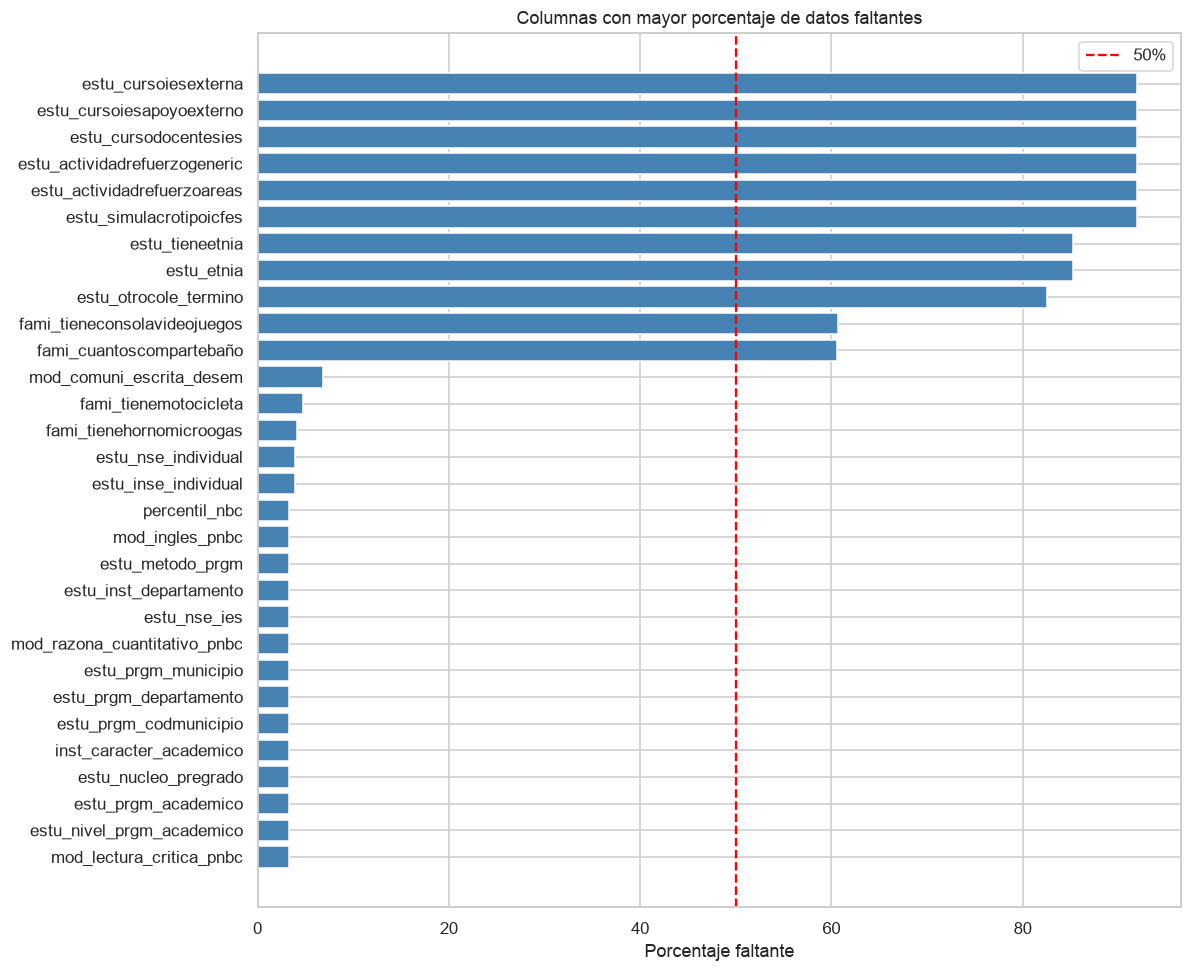

,faltantes_por_fila
count,"281,601.00"
mean,10.61
std,5.11
min,0.00
25%,9.00
50%,10.00
75%,11.00
max,56.00


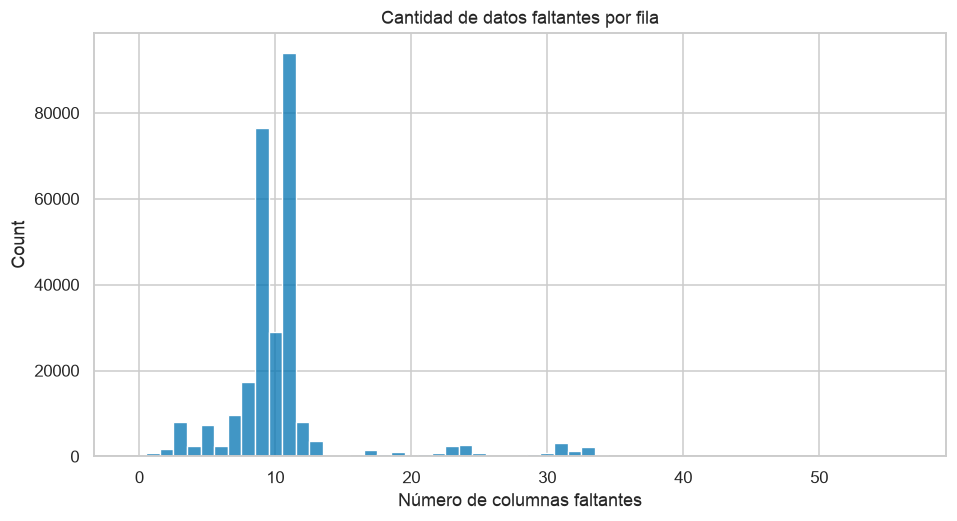

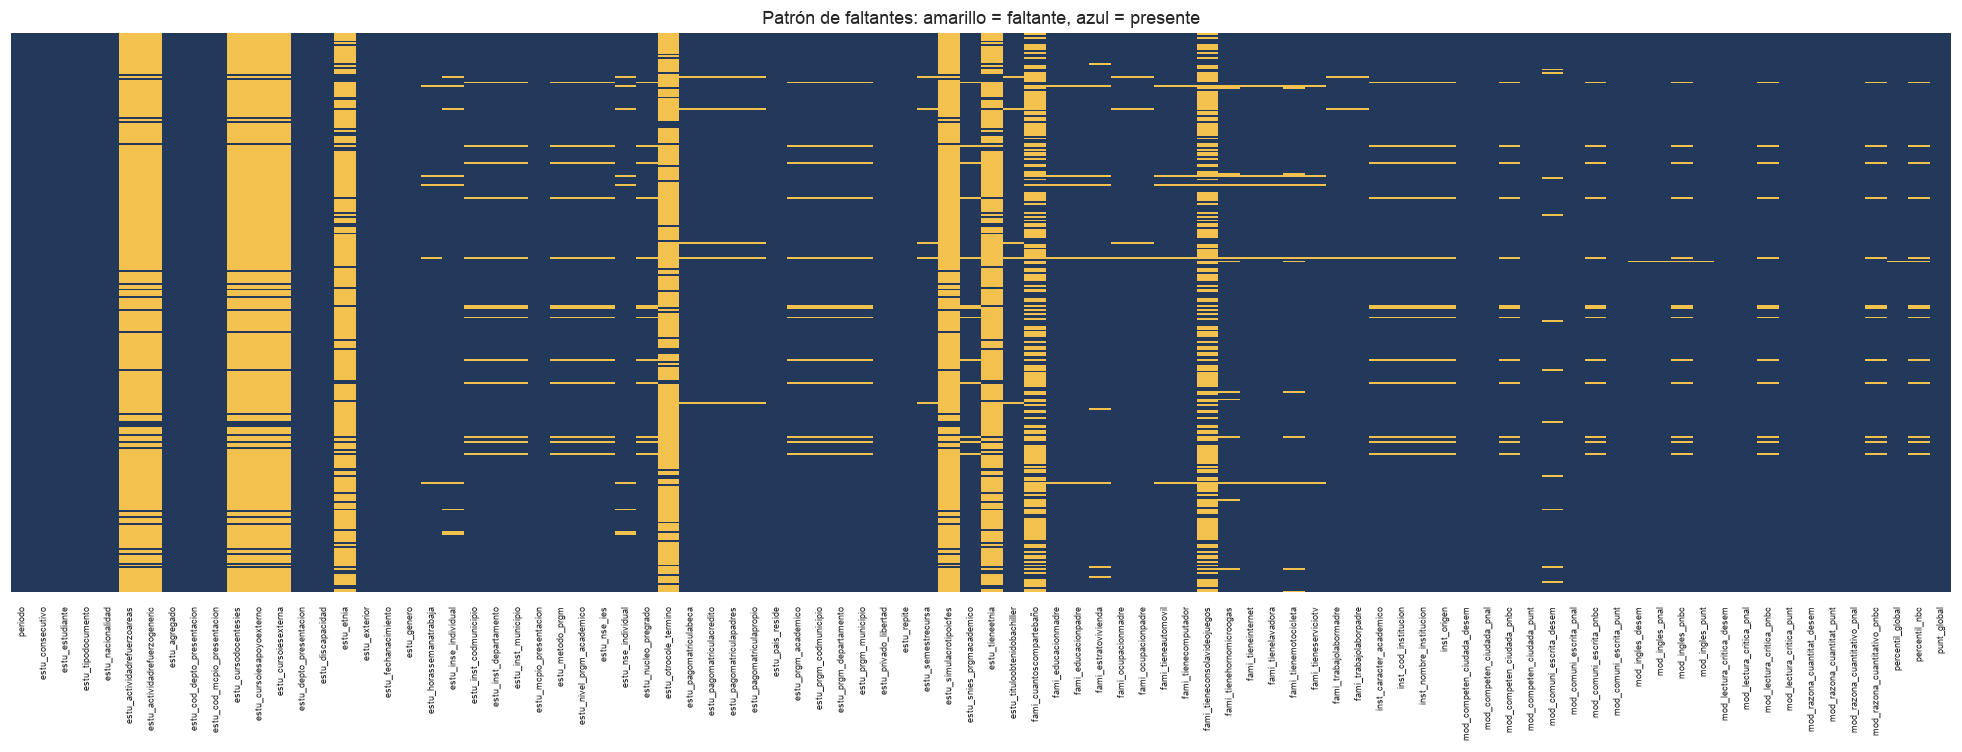

In [ ]:
# Faltantes por columna
missing_table = pd.DataFrame(index=df.columns)
missing_table['cantidad_faltante'] = df.isna().sum()
missing_table['porcentaje_faltante'] = df.isna().mean() * 100
missing_table = missing_table.sort_values('porcentaje_faltante', ascending=False)

total_missing = int(df.isna().sum().sum())
total_cells = df.shape[0] * df.shape[1]
print(f'Celdas faltantes: {total_missing:,} ({total_missing / total_cells * 100:.2f}%)')
print(f'Columnas con faltantes: {(missing_table.cantidad_faltante > 0).sum()}')
display(missing_table)

# Barras: columnas con más faltantes
top_missing = missing_table[missing_table['cantidad_faltante'] > 0].head(30)
top_missing = top_missing.sort_values('porcentaje_faltante')
plt.figure(figsize=(11, 9))
plt.barh(top_missing.index, top_missing['porcentaje_faltante'], color='steelblue')
plt.axvline(50, color='red', linestyle='--', label='50%')
plt.title('Columnas con mayor porcentaje de datos faltantes')
plt.xlabel('Porcentaje faltante')
plt.legend()
plt.tight_layout()
plt.show()

# Faltantes por fila
missing_per_row = df.isna().sum(axis=1)
display(missing_per_row.describe().to_frame('faltantes_por_fila'))
plt.figure(figsize=(10, 5))
sns.histplot(missing_per_row, discrete=True)
plt.title('Cantidad de datos faltantes por fila')
plt.xlabel('Número de columnas faltantes')
plt.show()

# Mapa del patrón de ausencia en una muestra
missing_sample = df.sample(min(300, len(df)), random_state=RANDOM_STATE).isna()
plt.figure(figsize=(18, 7))
sns.heatmap(missing_sample, cmap=['#23395B', '#F2C14E'], cbar=False, yticklabels=False)
plt.title('Patrón de faltantes: amarillo = faltante, azul = presente')
plt.xticks(rotation=90, fontsize=6)
plt.tight_layout()
plt.show()

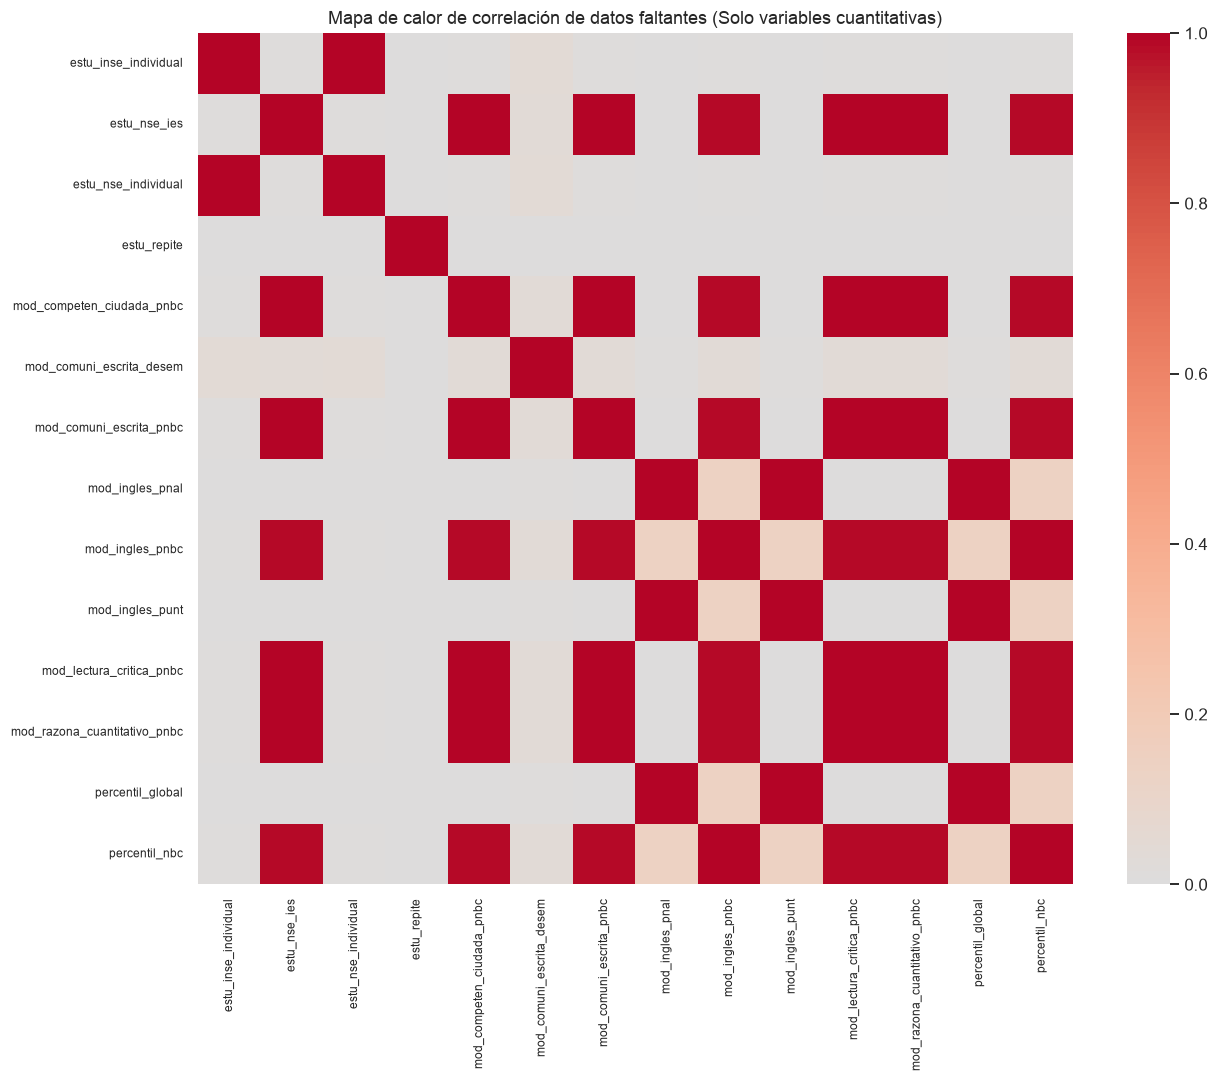

Fechas no interpretables: 0
Fecha mínima: 0001-03-24 00:00:00
Fecha máxima: 2024-07-02 00:00:00


,edad_aproximada_en_2024
count,"281,599.00"
mean,28.20
std,33.49
min,0.50
25%,23.01
50%,25.02
75%,30.03
max,"2,023.73"


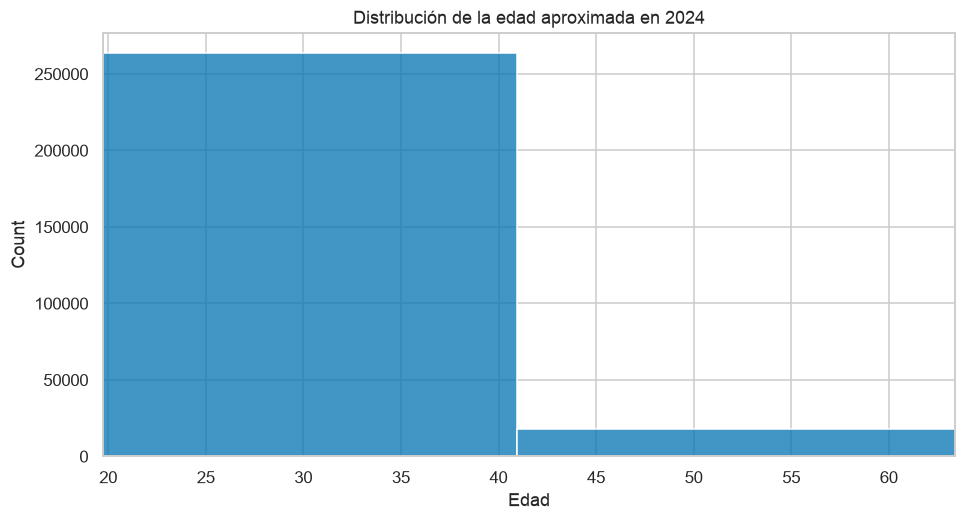

In [41]:
# Columnas que tienen algunos datos faltantes
quant_columns_with_missing = [
    column for column in numeric_columns 
    if 0 < df[column].isna().sum() < len(df)
]

# Mapa de correlación: Valores cercanos a 1 (las dos columnas suelen faltar juntas)
if quant_columns_with_missing:
    missing_correlation = df[quant_columns_with_missing].isna().corr()

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        missing_correlation, 
        cmap='coolwarm', 
        center=0, 
        vmin=0, 
        vmax=1,
        annot=False,
        fmt=".2f"
    )
    plt.title('Mapa de calor de correlación de datos faltantes (Solo variables cuantitativas)')
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("No hay variables cuantitativas que tengan datos faltantes para analizar.")

# Fecha de nacimiento: diagnóstico en una serie auxiliar
birth_date = pd.to_datetime(df['estu_fechanacimiento'], dayfirst=True, errors='coerce')
invalid_dates = df['estu_fechanacimiento'].notna().sum() - birth_date.notna().sum()
age_2024 = (pd.Timestamp('2024-12-31') - birth_date).dt.days / 365.25

print('Fechas no interpretables:', invalid_dates)
print('Fecha mínima:', birth_date.min())
print('Fecha máxima:', birth_date.max())
display(age_2024.describe().to_frame('edad_aproximada_en_2024'))

plt.figure(figsize=(10, 5))
sns.histplot(age_2024.dropna(), bins=50)
plt.title('Distribución de la edad aproximada en 2024')
plt.xlabel('Edad')
plt.xlim(age_2024.quantile(0.001), age_2024.quantile(0.999))
plt.show()

## 4. Estadísticas y distribuciones numéricas

Las estadísticas usan todas las filas. Las gráficas usan una muestra reproducible para que el notebook sea más rápido.

,count,mean,std,min,25%,50%,75%,max,mediana,faltantes,faltantes_pct,asimetria
estu_inse_individual,"270,610.00",49.71,10.07,11.64,42.77,48.85,55.78,84.97,48.85,10991,3.90,0.40
estu_nse_ies,"272,448.00",2.45,0.83,1.00,2.00,2.00,3.00,4.00,2.00,9153,3.25,0.73
estu_nse_individual,"270,610.00",2.44,1.11,1.00,2.00,2.00,4.00,4.00,2.00,10991,3.90,0.22
estu_repite,"281,599.00","5,671.02","28,179.75",0.00,0.00,0.00,0.00,"219,704.00",0.00,2,0.00,5.45
mod_competen_ciudada_desem,"281,601.00",2.14,0.88,1.00,1.00,2.00,3.00,4.00,2.00,0,0.00,0.11
mod_competen_ciudada_pnal,"281,601.00",49.94,28.95,1.00,25.00,50.00,75.00,100.00,50.00,0,0.00,0.02
mod_competen_ciudada_pnbc,"272,448.00",50.26,28.95,1.00,25.00,50.00,75.00,100.00,50.00,9153,3.25,0.01
mod_competen_ciudada_punt,"281,601.00",145.22,32.97,0.00,121.00,146.00,169.00,300.00,146.00,0,0.00,0.00
mod_comuni_escrita_desem,"262,244.00",2.37,0.74,1.00,2.00,2.00,3.00,4.00,2.00,19357,6.87,-0.14
mod_comuni_escrita_pnal,"281,601.00",46.89,30.46,1.00,20.00,46.00,73.00,100.00,46.00,0,0.00,0.05


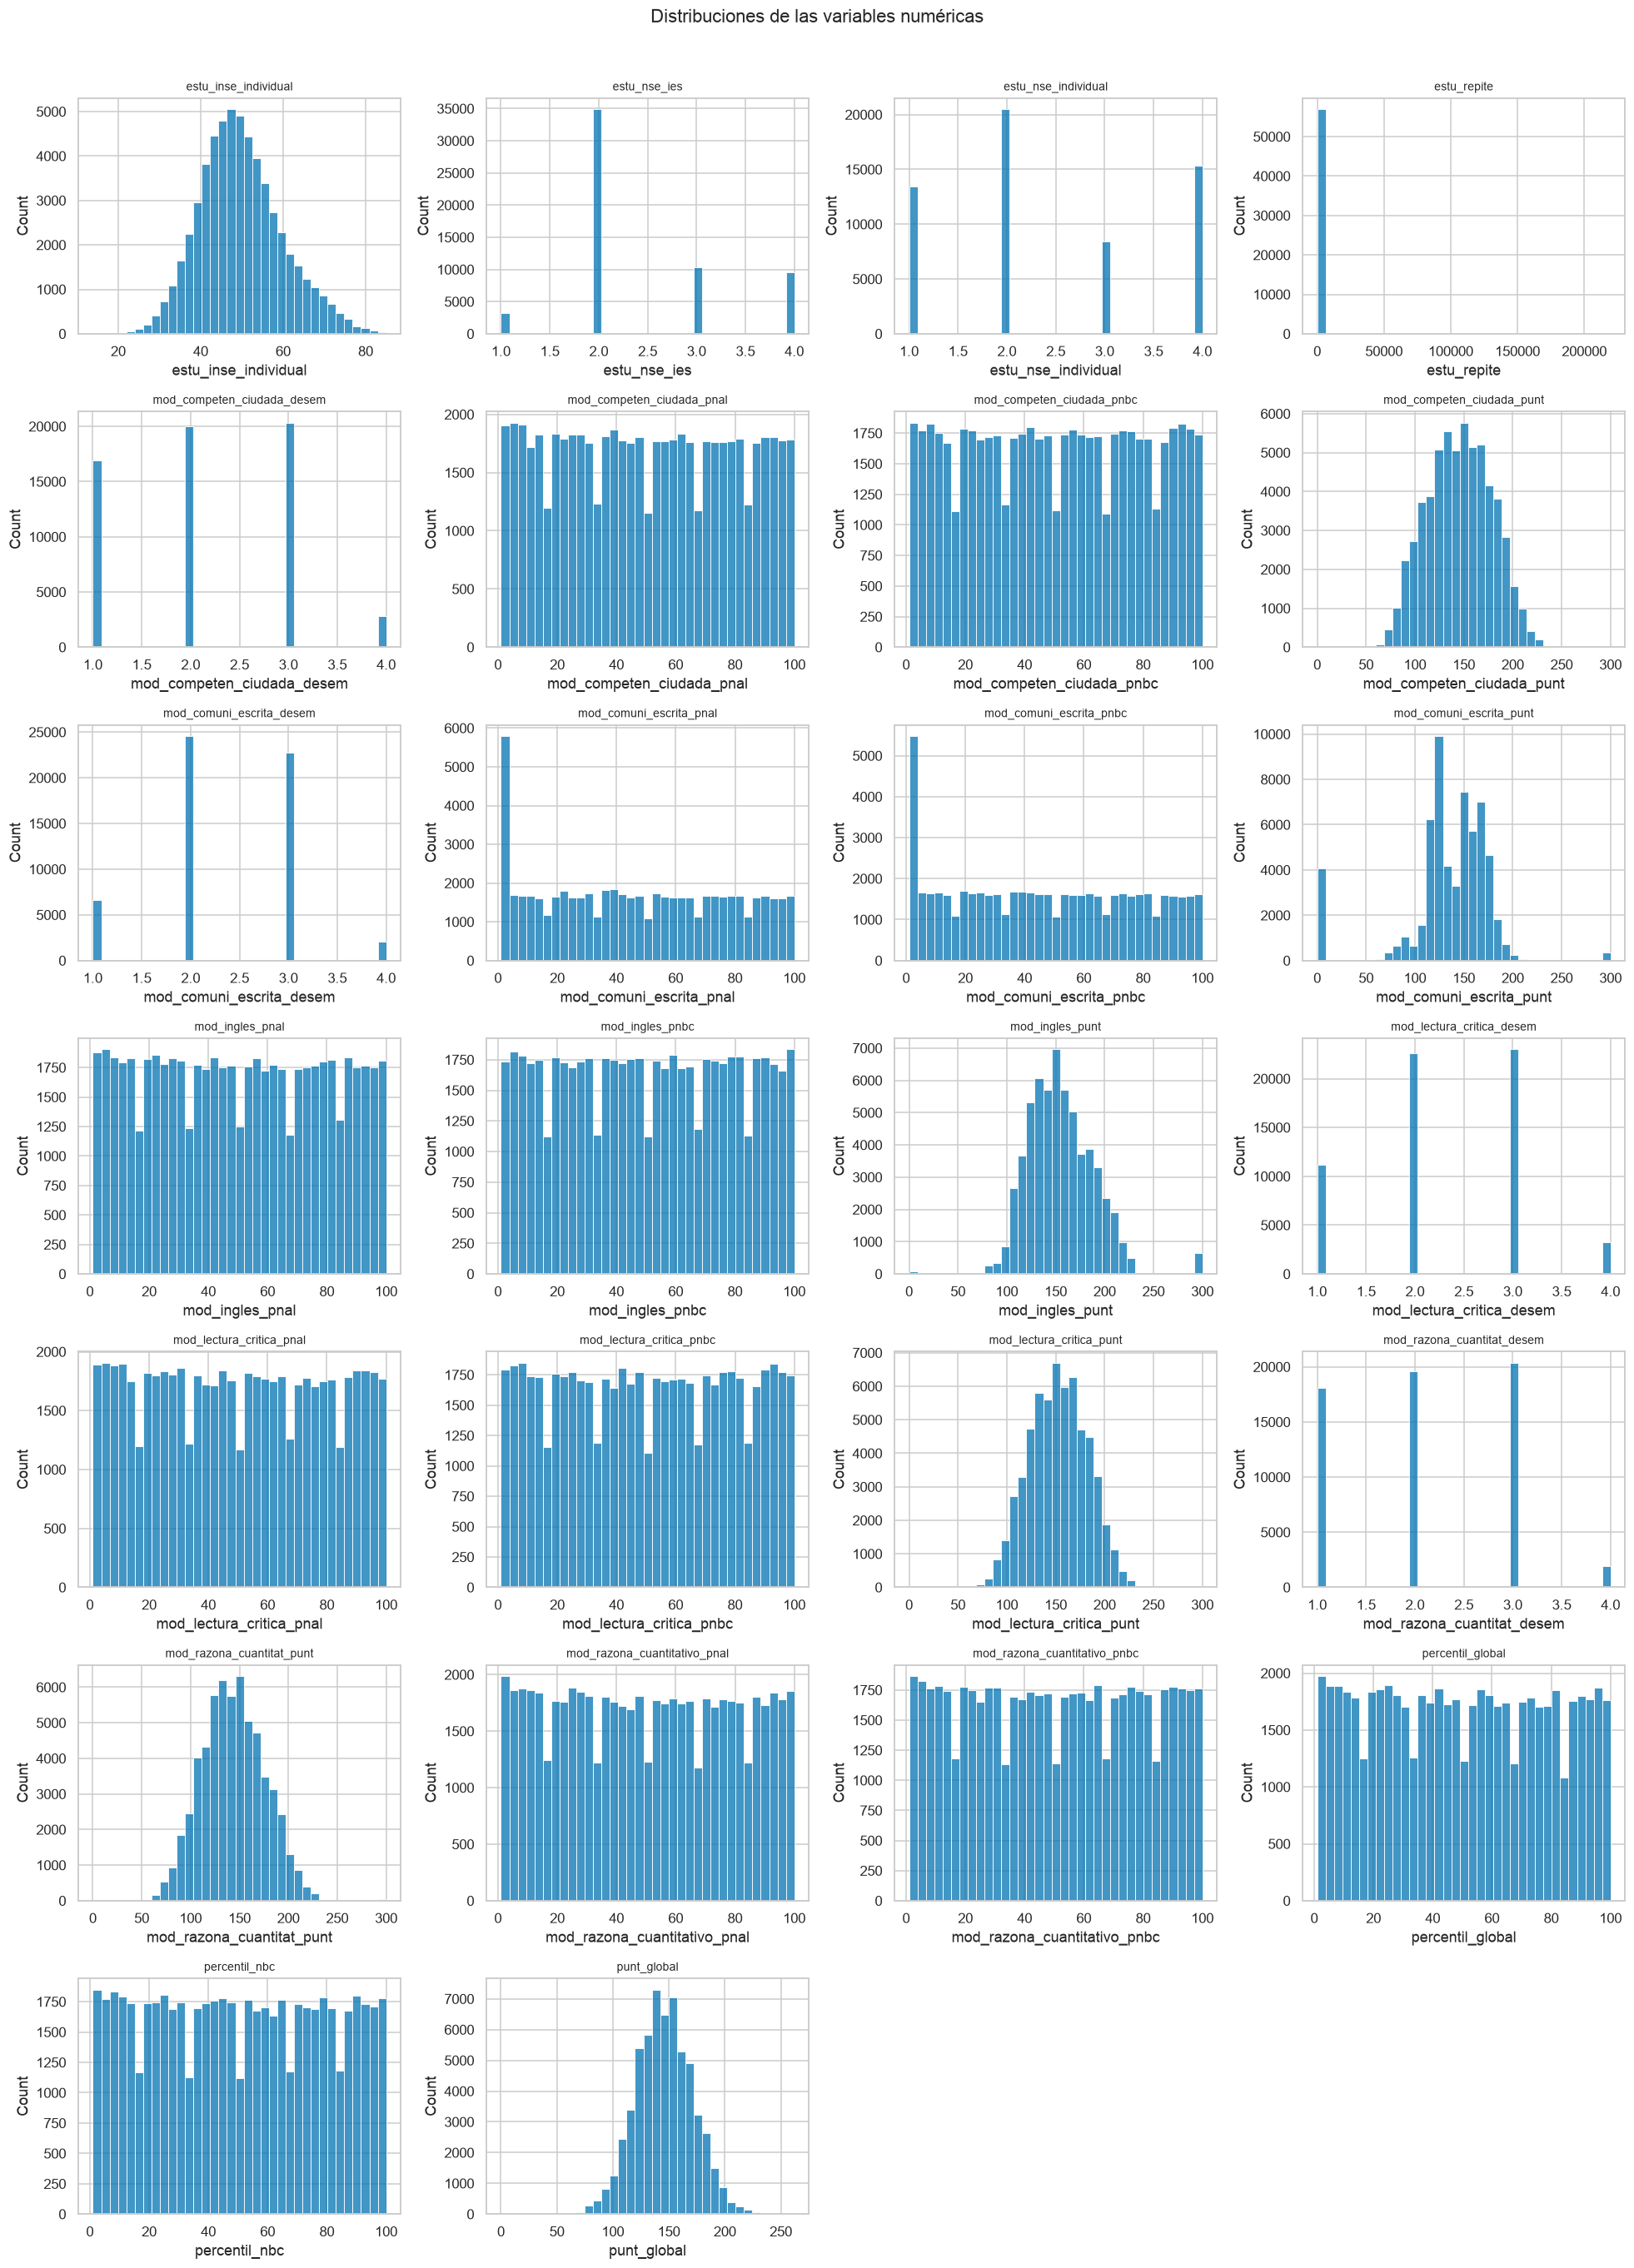

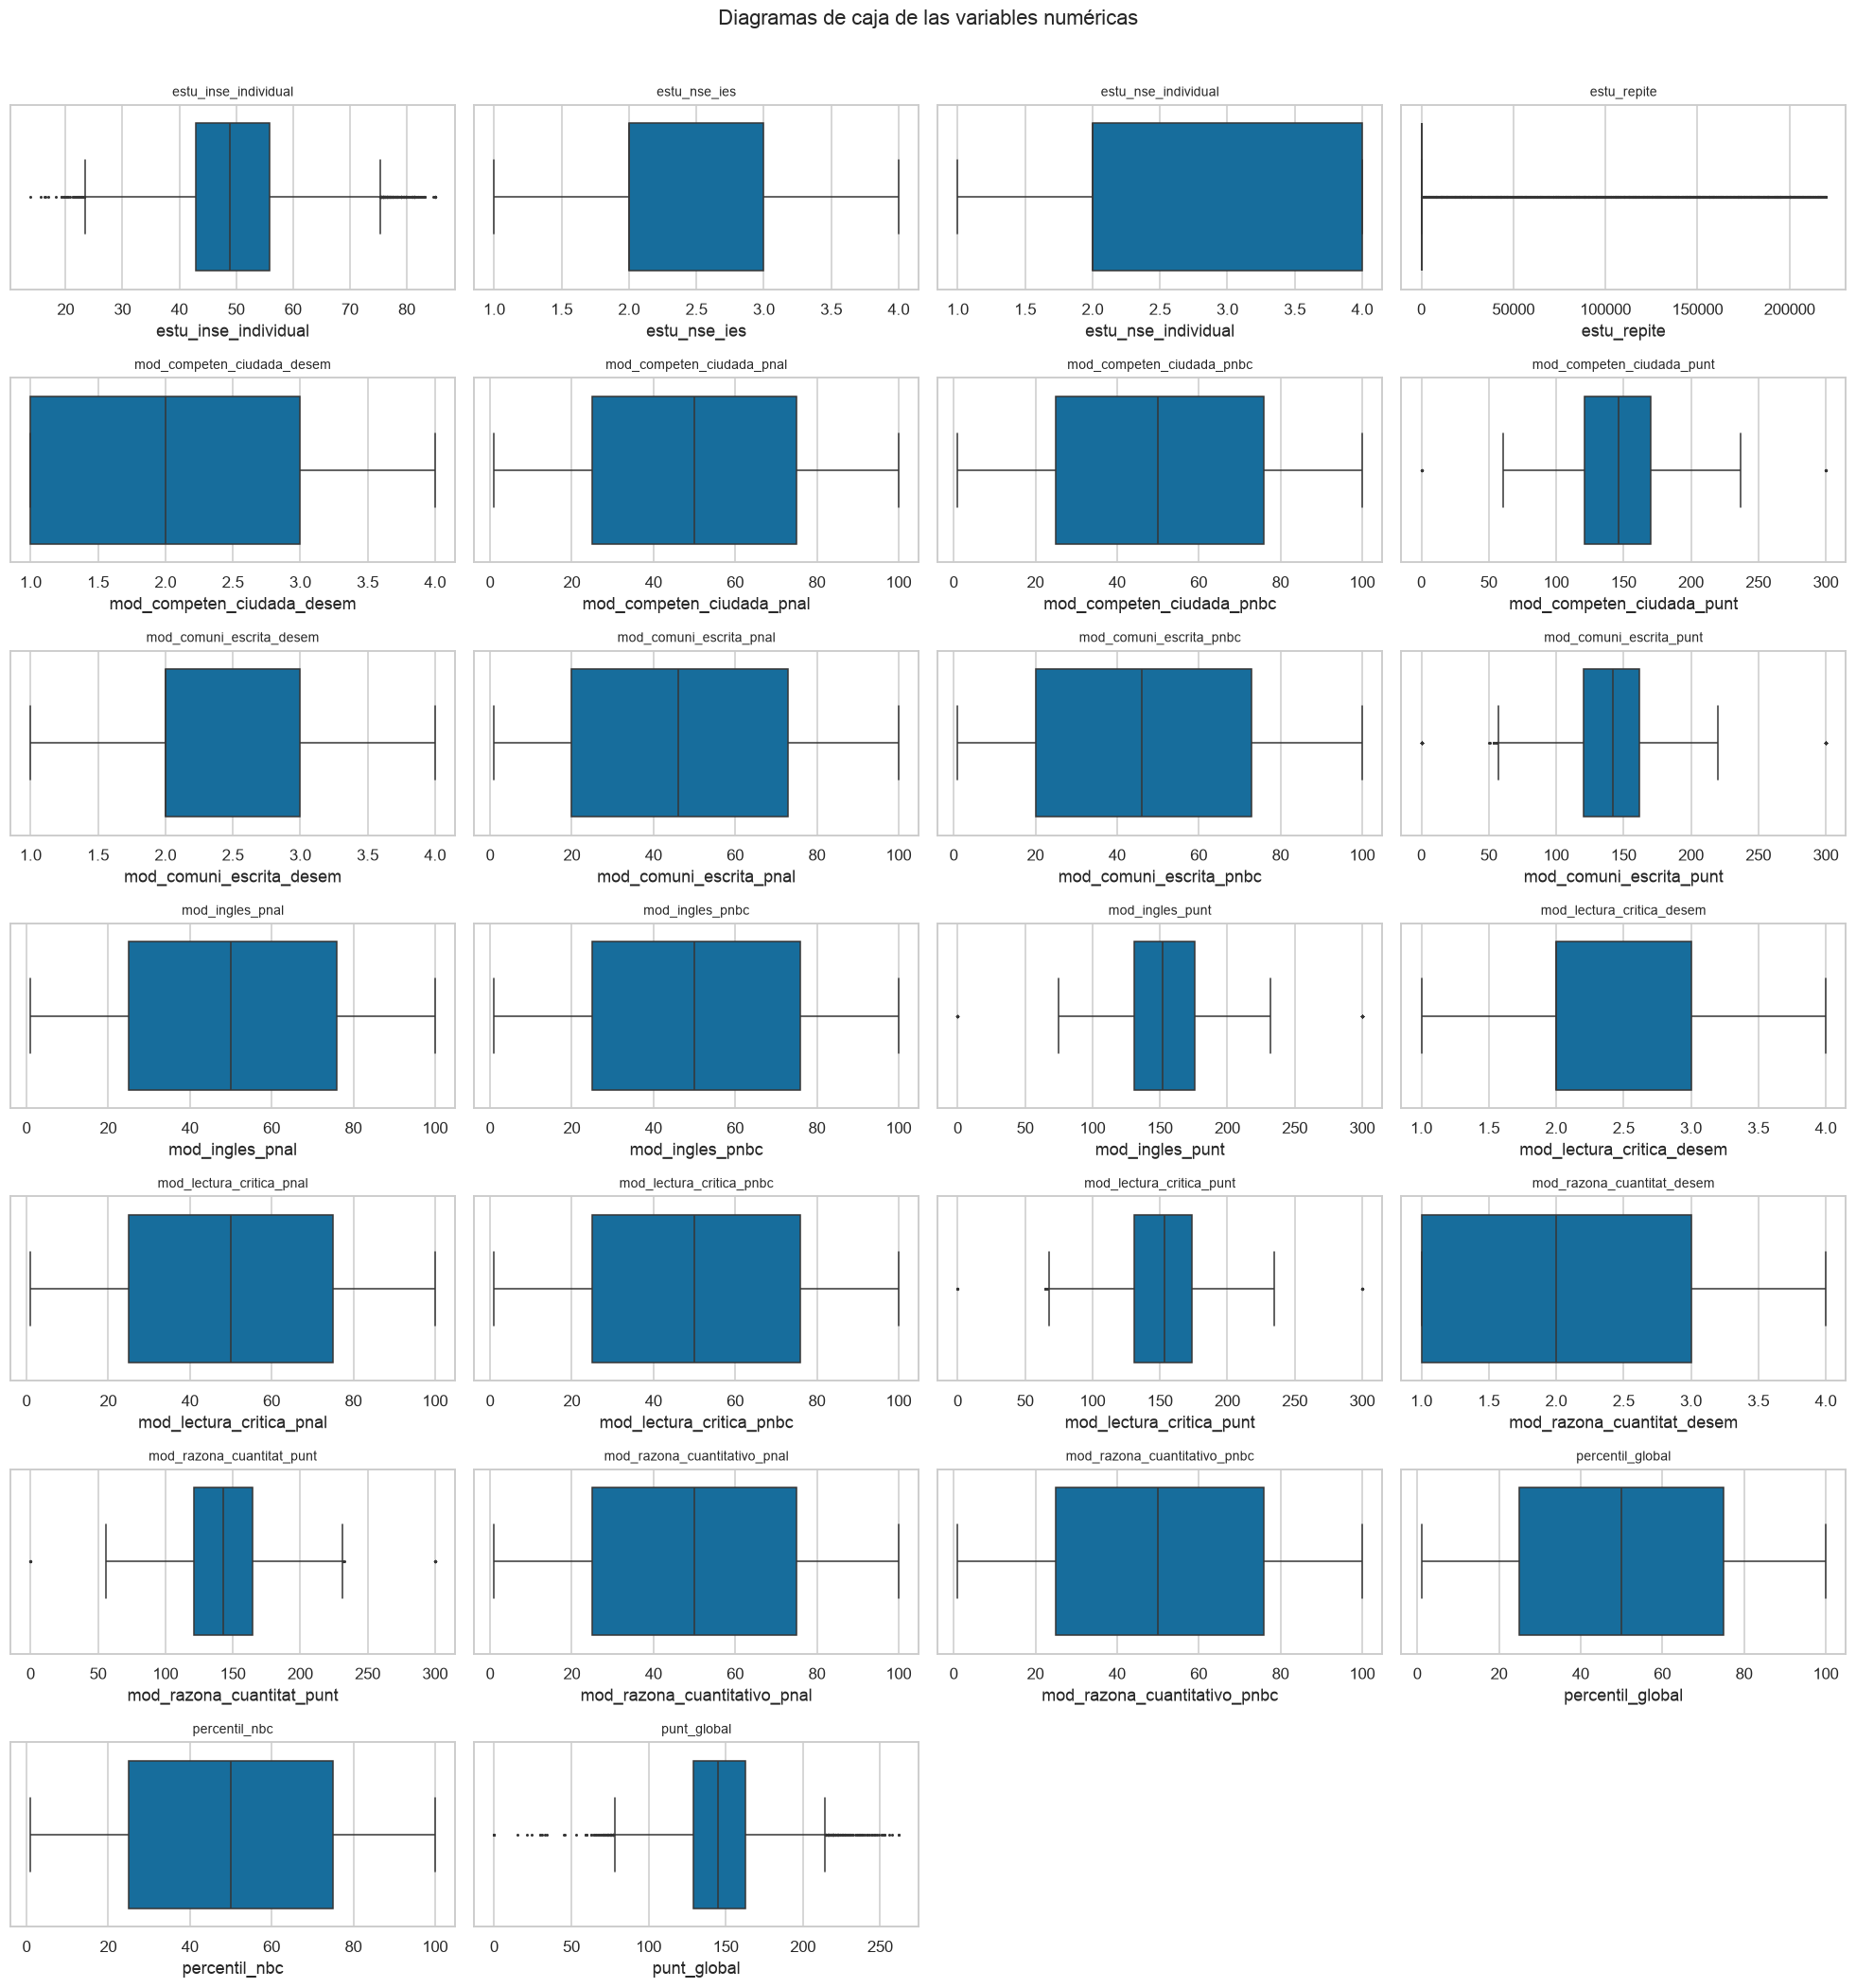

In [42]:
# Estadísticas descriptivas
numeric_stats = df[numeric_columns].describe().T
numeric_stats['mediana'] = df[numeric_columns].median()
numeric_stats['faltantes'] = df[numeric_columns].isna().sum()
numeric_stats['faltantes_pct'] = df[numeric_columns].isna().mean() * 100
numeric_stats['asimetria'] = df[numeric_columns].skew()
display(numeric_stats)

# Muestra usada solamente para las gráficas
plot_sample = df[numeric_columns].sample(min(PLOT_SAMPLE_SIZE, len(df)), random_state=RANDOM_STATE)
columns_per_row = 4
rows_needed = math.ceil(len(numeric_columns) / columns_per_row)

# Histogramas
fig, axes = plt.subplots(rows_needed, columns_per_row, figsize=(18, 3.5 * rows_needed))
axes = np.array(axes).reshape(-1)
for position, column in enumerate(numeric_columns):
    sns.histplot(plot_sample[column].dropna(), bins=35, ax=axes[position])
    axes[position].set_title(column, fontsize=9)
for position in range(len(numeric_columns), len(axes)):
    axes[position].axis('off')
plt.suptitle('Distribuciones de las variables numéricas', y=1.01)
plt.tight_layout()
plt.show()

# Diagramas de caja
fig, axes = plt.subplots(rows_needed, columns_per_row, figsize=(18, 2.7 * rows_needed))
axes = np.array(axes).reshape(-1)
for position, column in enumerate(numeric_columns):
    sns.boxplot(x=plot_sample[column], ax=axes[position], fliersize=1)
    axes[position].set_title(column, fontsize=9)
for position in range(len(numeric_columns), len(axes)):
    axes[position].axis('off')
plt.suptitle('Diagramas de caja de las variables numéricas', y=1.01)
plt.tight_layout()
plt.show()

## 5. Posibles valores atípicos

Se usa la regla IQR: un valor se marca si está por debajo de $Q_1 - 1.5\times IQR$ o por encima de $Q_3 + 1.5\times IQR$. Marcarlo no significa que sea incorrecto. En esta fase no se elimina ni modifica ningún dato.

,variable,limite_inferior,limite_superior,cantidad_atipicos,porcentaje_atipicos
11,mod_comuni_escrita_punt,57.00,225.00,20935,7.43
3,estu_repite,0.00,0.00,14665,5.21
14,mod_ingles_punt,63.50,243.50,3497,1.24
0,estu_inse_individual,23.26,75.29,3331,1.23
25,punt_global,78.00,214.00,2301,0.82
20,mod_razona_cuantitat_punt,55.00,231.00,415,0.15
7,mod_competen_ciudada_punt,49.00,241.00,335,0.12
18,mod_lectura_critica_punt,68.00,236.00,312,0.11
4,mod_competen_ciudada_desem,-2.00,6.00,0,0.00
1,estu_nse_ies,0.50,4.50,0,0.00


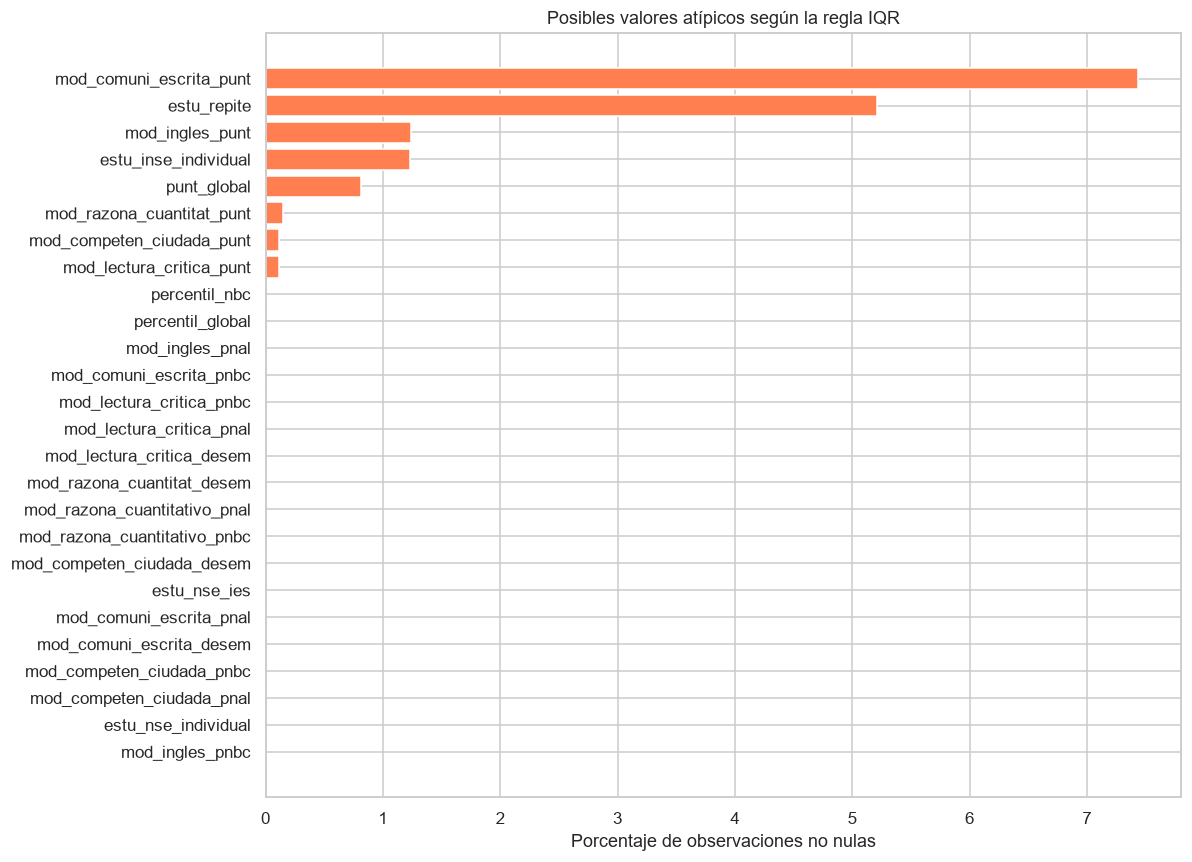

In [ ]:
# Resumen de posibles atípicos para cada variable numérica
outlier_results = []

for column in numeric_columns:
    values = df[column].dropna()
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr
    outlier_count = ((values < lower_limit) | (values > upper_limit)).sum()
    outlier_percentage = outlier_count / len(values) * 100

    outlier_results.append({
        'variable': column,
        'limite_inferior': lower_limit,
        'limite_superior': upper_limit,
        'cantidad_atipicos': outlier_count,
        'porcentaje_atipicos': outlier_percentage
    })

outlier_summary = pd.DataFrame(outlier_results).sort_values('porcentaje_atipicos', ascending=False)
display(outlier_summary)

chart_data = outlier_summary.sort_values('porcentaje_atipicos')
plt.figure(figsize=(11, 8))
plt.barh(chart_data['variable'], chart_data['porcentaje_atipicos'], color='coral')
plt.title('Posibles valores atípicos según la regla IQR')
plt.xlabel('Porcentaje de observaciones no nulas')
plt.tight_layout()
plt.show()

## 6. Variables categóricas

La tabla resume todas las variables categóricas. Las gráficas muestran únicamente variables importantes y sus diez categorías más frecuentes para conservar la legibilidad.

,variable,categorias_unicas,faltantes_pct,categoria_mas_frecuente,frecuencia_categoria_principal
1,estu_consecutivo,281601,0.00,EK202410009172,1
26,estu_otrocole_termino,37175,82.59,INSTITUCION EDUCATIVA GENERAL SANTANDER,42
39,estu_snies_prgmacademico,4330,3.25,"110,234.00",3954
32,estu_prgm_academico,944,3.25,DERECHO,19303
60,inst_nombre_institucion,270,3.25,CORPORACION UNIVERSITARIA MINUTO DE DIOS -UNIM...,13535
59,inst_cod_institucion,270,3.25,"2,829.00",13535
33,estu_prgm_codmunicipio,116,3.25,"11,001.00",112806
35,estu_prgm_municipio,115,3.25,BOGOTÁ D.C.,112806
9,estu_cod_mcpio_presentacion,109,0.00,11001,76256
22,estu_mcpio_presentacion,108,0.00,BOGOTÁ D.C.,76256


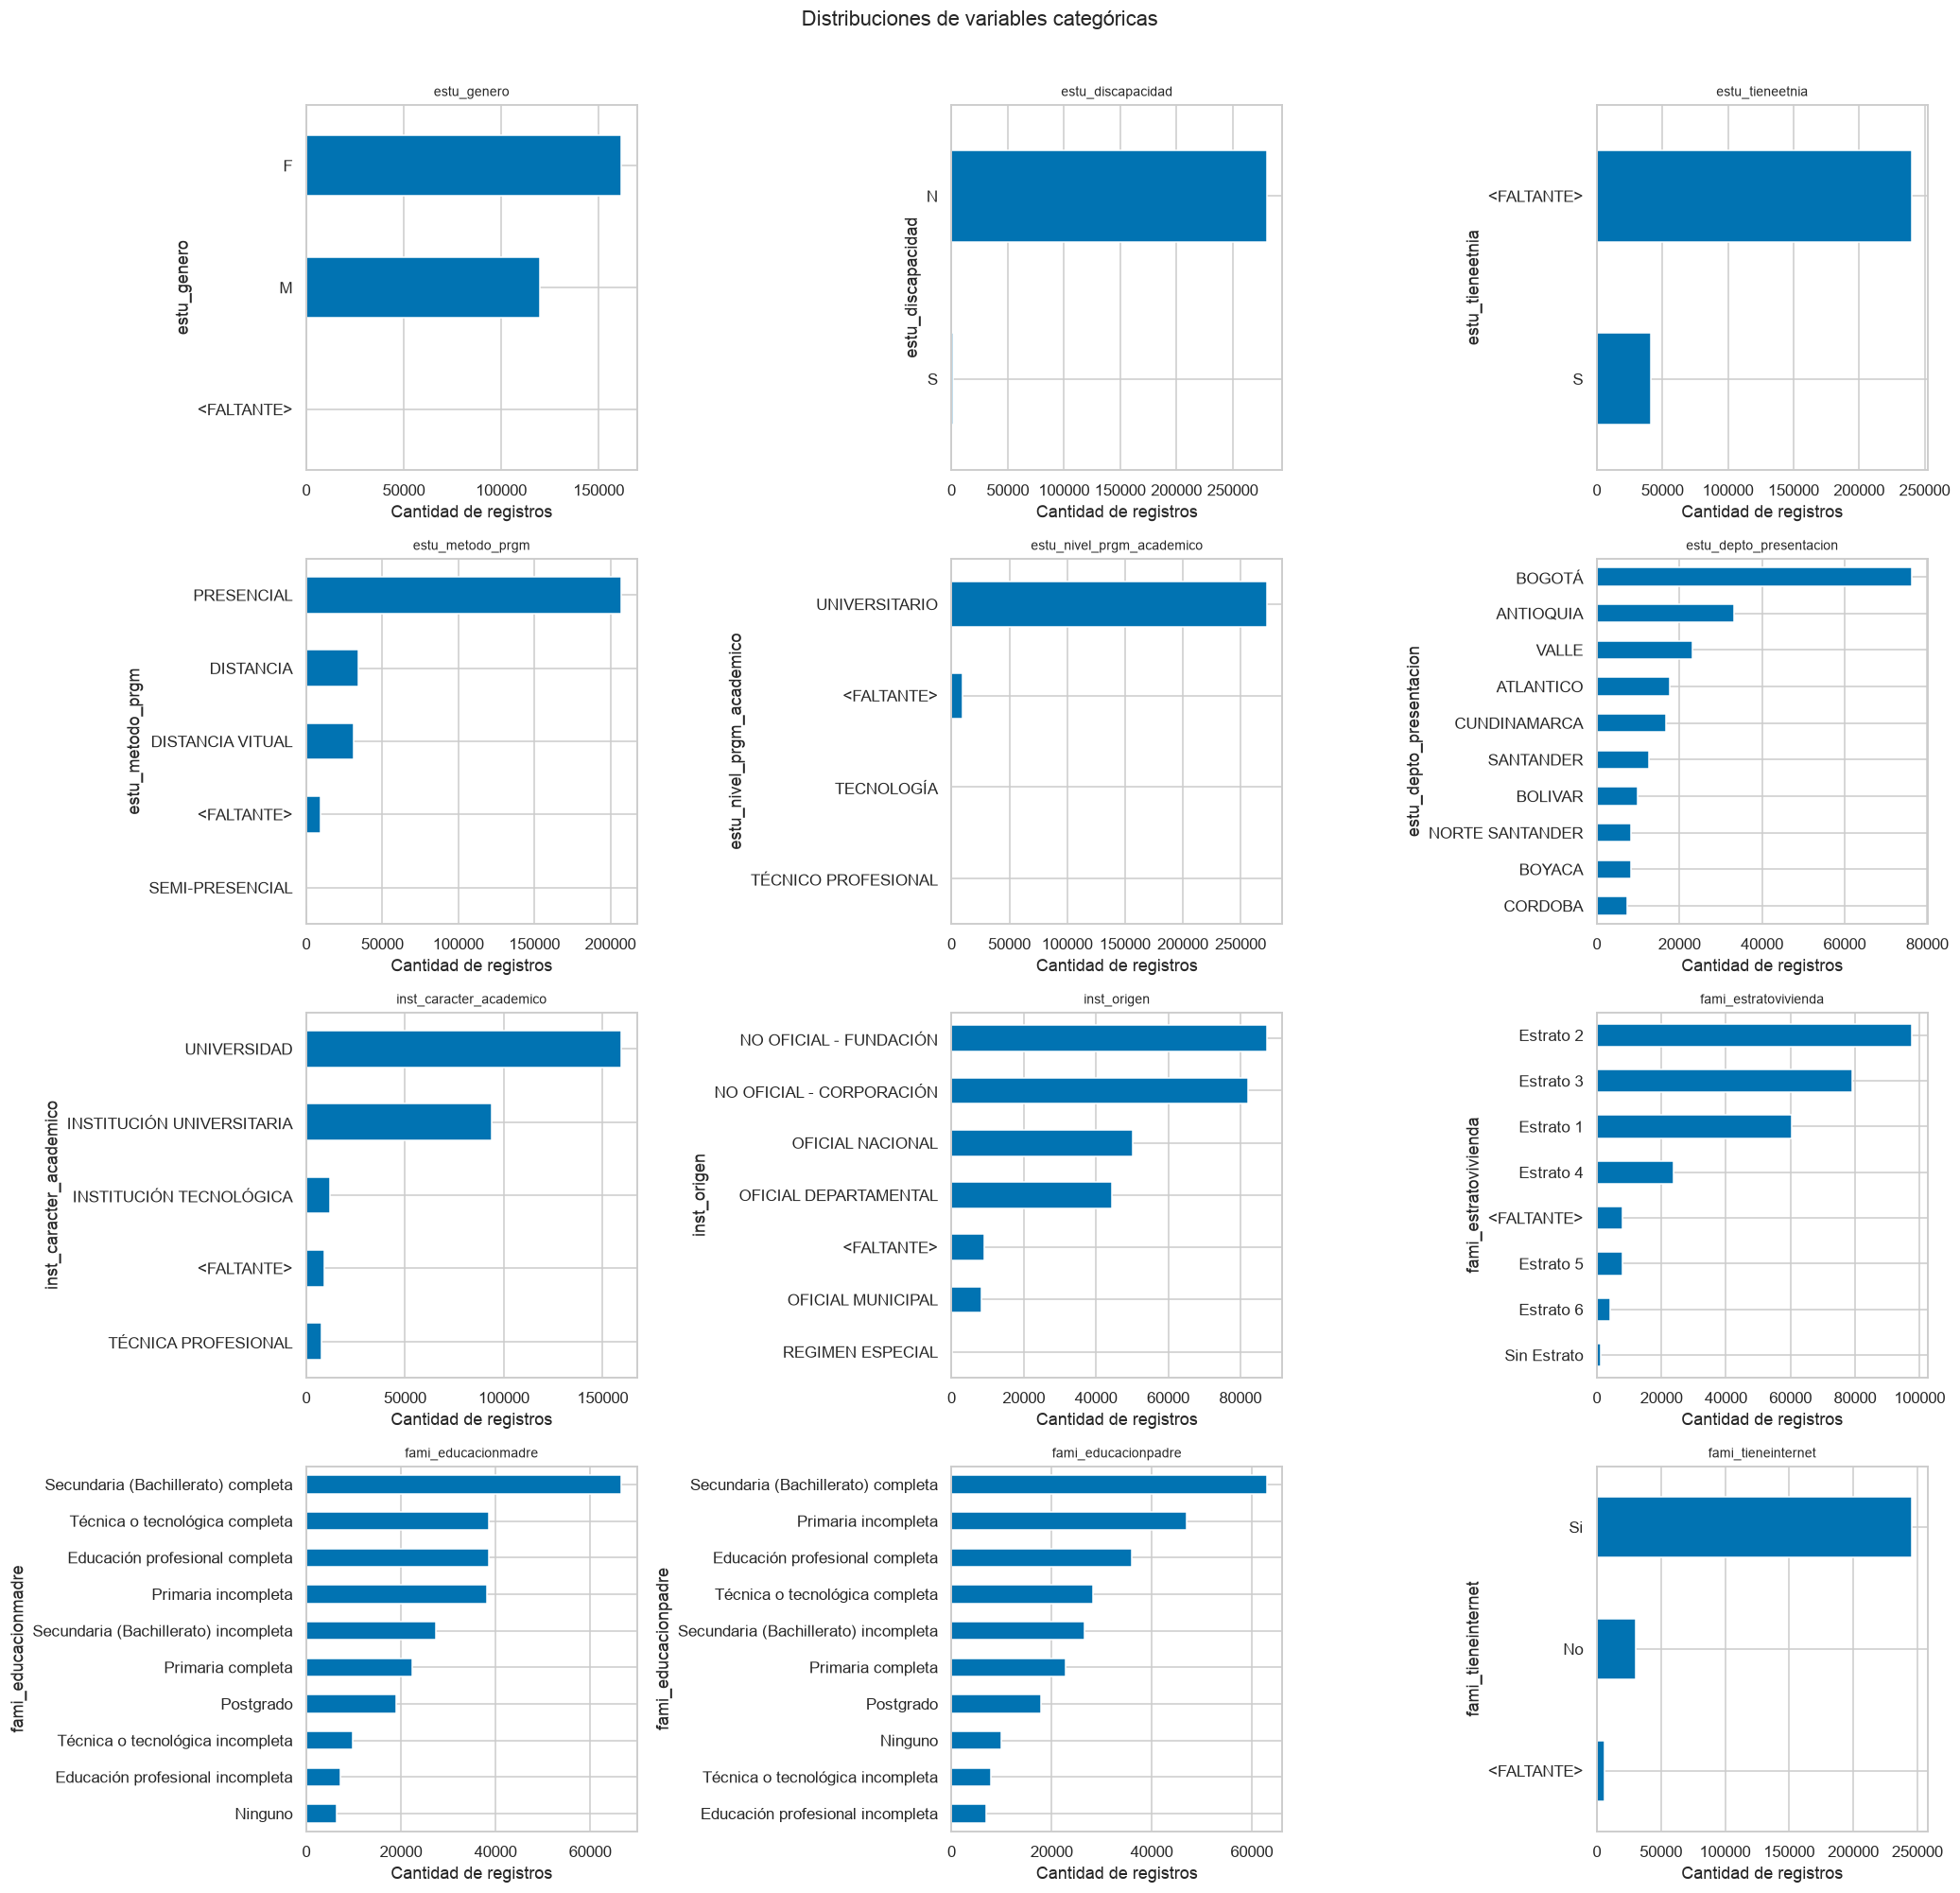

In [43]:
# Resumen de categorías
categorical_results = []
for column in categorical_columns:
    counts = df[column].value_counts(dropna=True)
    most_common = counts.index[0] if len(counts) > 0 else np.nan
    most_common_count = counts.iloc[0] if len(counts) > 0 else 0
    categorical_results.append({
        'variable': column,
        'categorias_unicas': df[column].nunique(dropna=True),
        'faltantes_pct': df[column].isna().mean() * 100,
        'categoria_mas_frecuente': most_common,
        'frecuencia_categoria_principal': most_common_count
    })

categorical_summary = pd.DataFrame(categorical_results)
display(categorical_summary.sort_values('categorias_unicas', ascending=False))

selected_categories = [
    'estu_genero', 'estu_discapacidad', 'estu_tieneetnia',
    'estu_metodo_prgm', 'estu_nivel_prgm_academico',
    'estu_depto_presentacion', 'inst_caracter_academico',
    'inst_origen', 'fami_estratovivienda', 'fami_educacionmadre',
    'fami_educacionpadre', 'fami_tieneinternet'
]
selected_categories = [column for column in selected_categories if column in df.columns]

fig, axes = plt.subplots(4, 3, figsize=(19, 18))
axes = axes.reshape(-1)
for position, column in enumerate(selected_categories):
    counts = df[column].fillna('<FALTANTE>').value_counts().head(10).sort_values()
    counts.plot(kind='barh', ax=axes[position])
    axes[position].set_title(column, fontsize=9)
    axes[position].set_xlabel('Cantidad de registros')
for position in range(len(selected_categories), len(axes)):
    axes[position].axis('off')
plt.suptitle('Distribuciones de variables categóricas', y=1.01)
plt.tight_layout()
plt.show()

## 7. Correlaciones entre métricas

Pearson describe relaciones lineales y Spearman relaciones que aumentan o disminuyen de manera consistente. Los códigos e identificadores no se incluyen. Una correlación no demuestra causalidad.

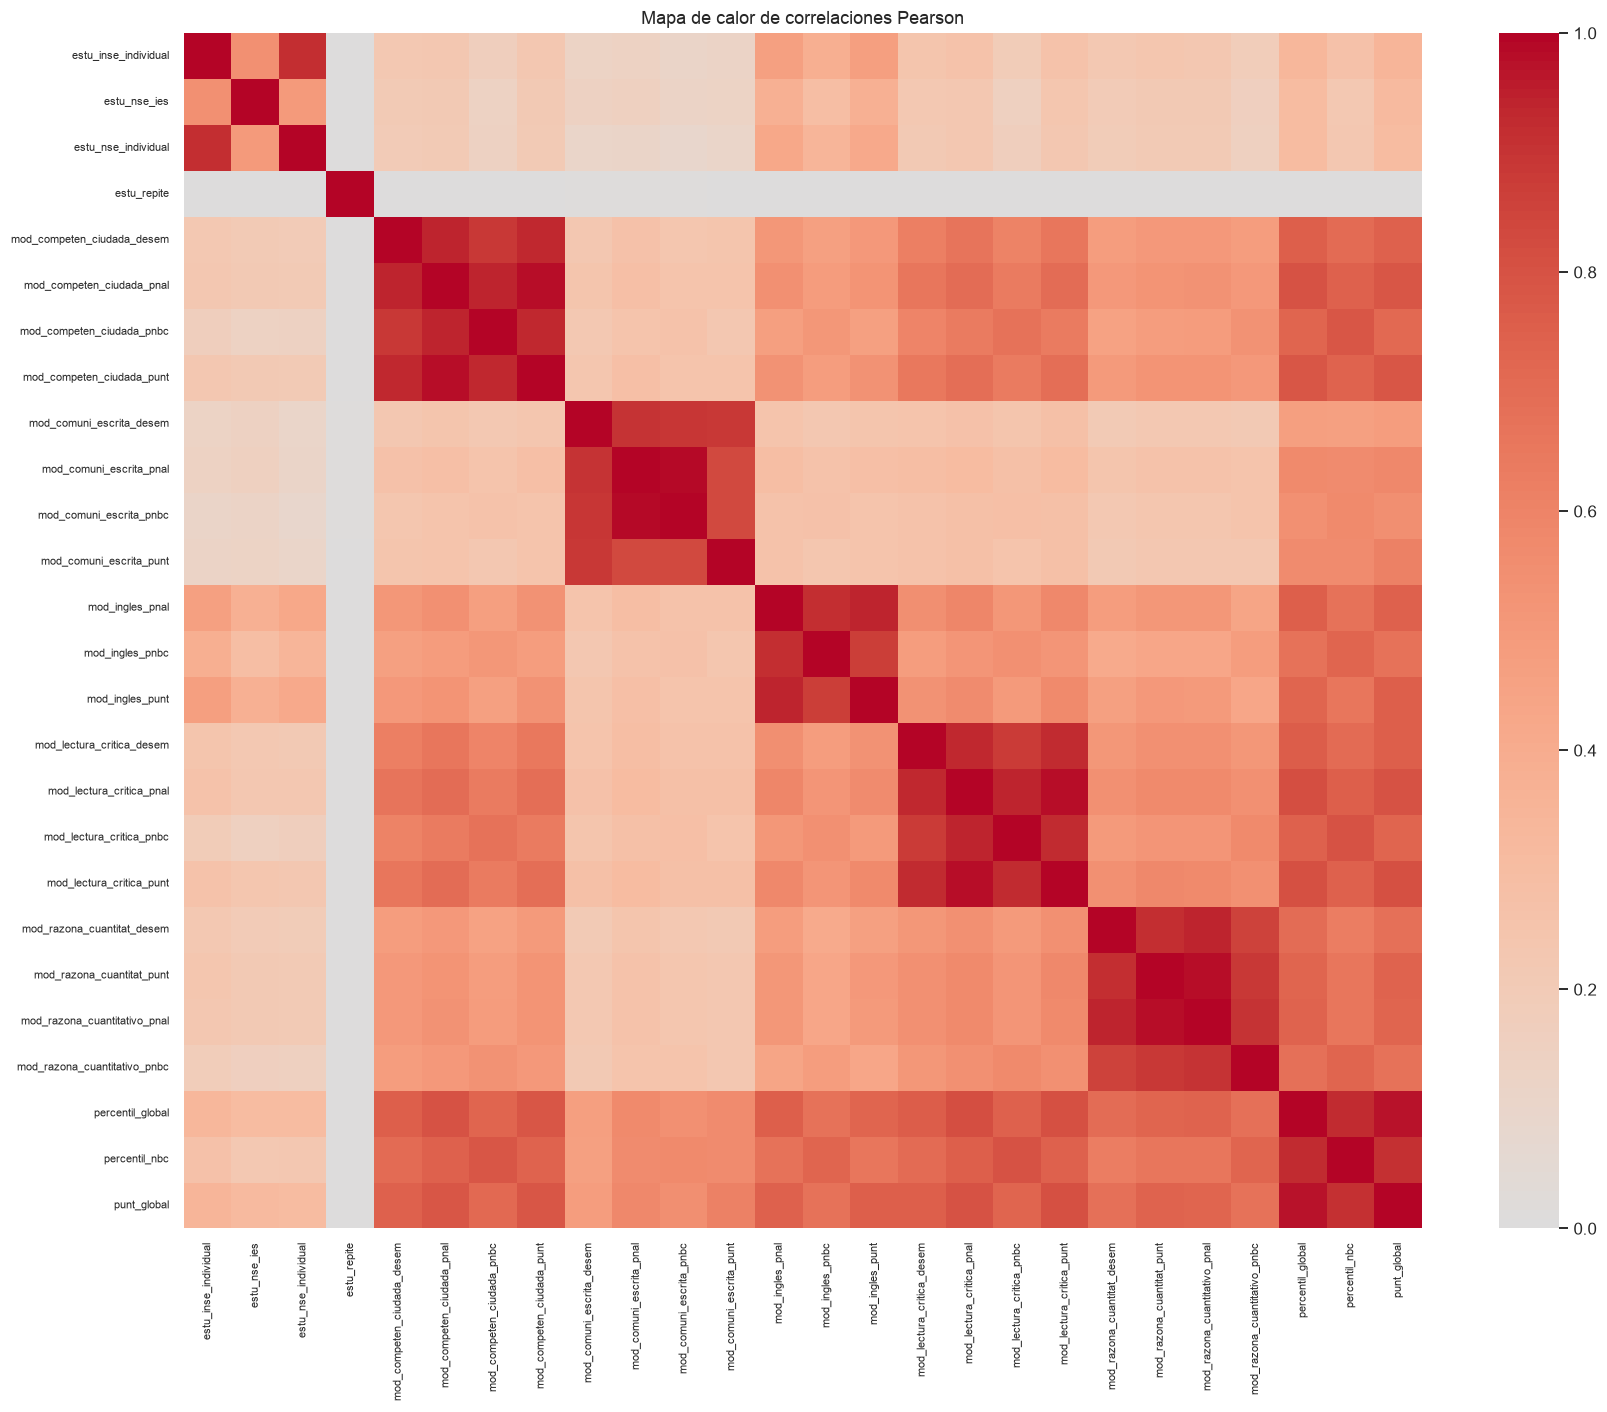

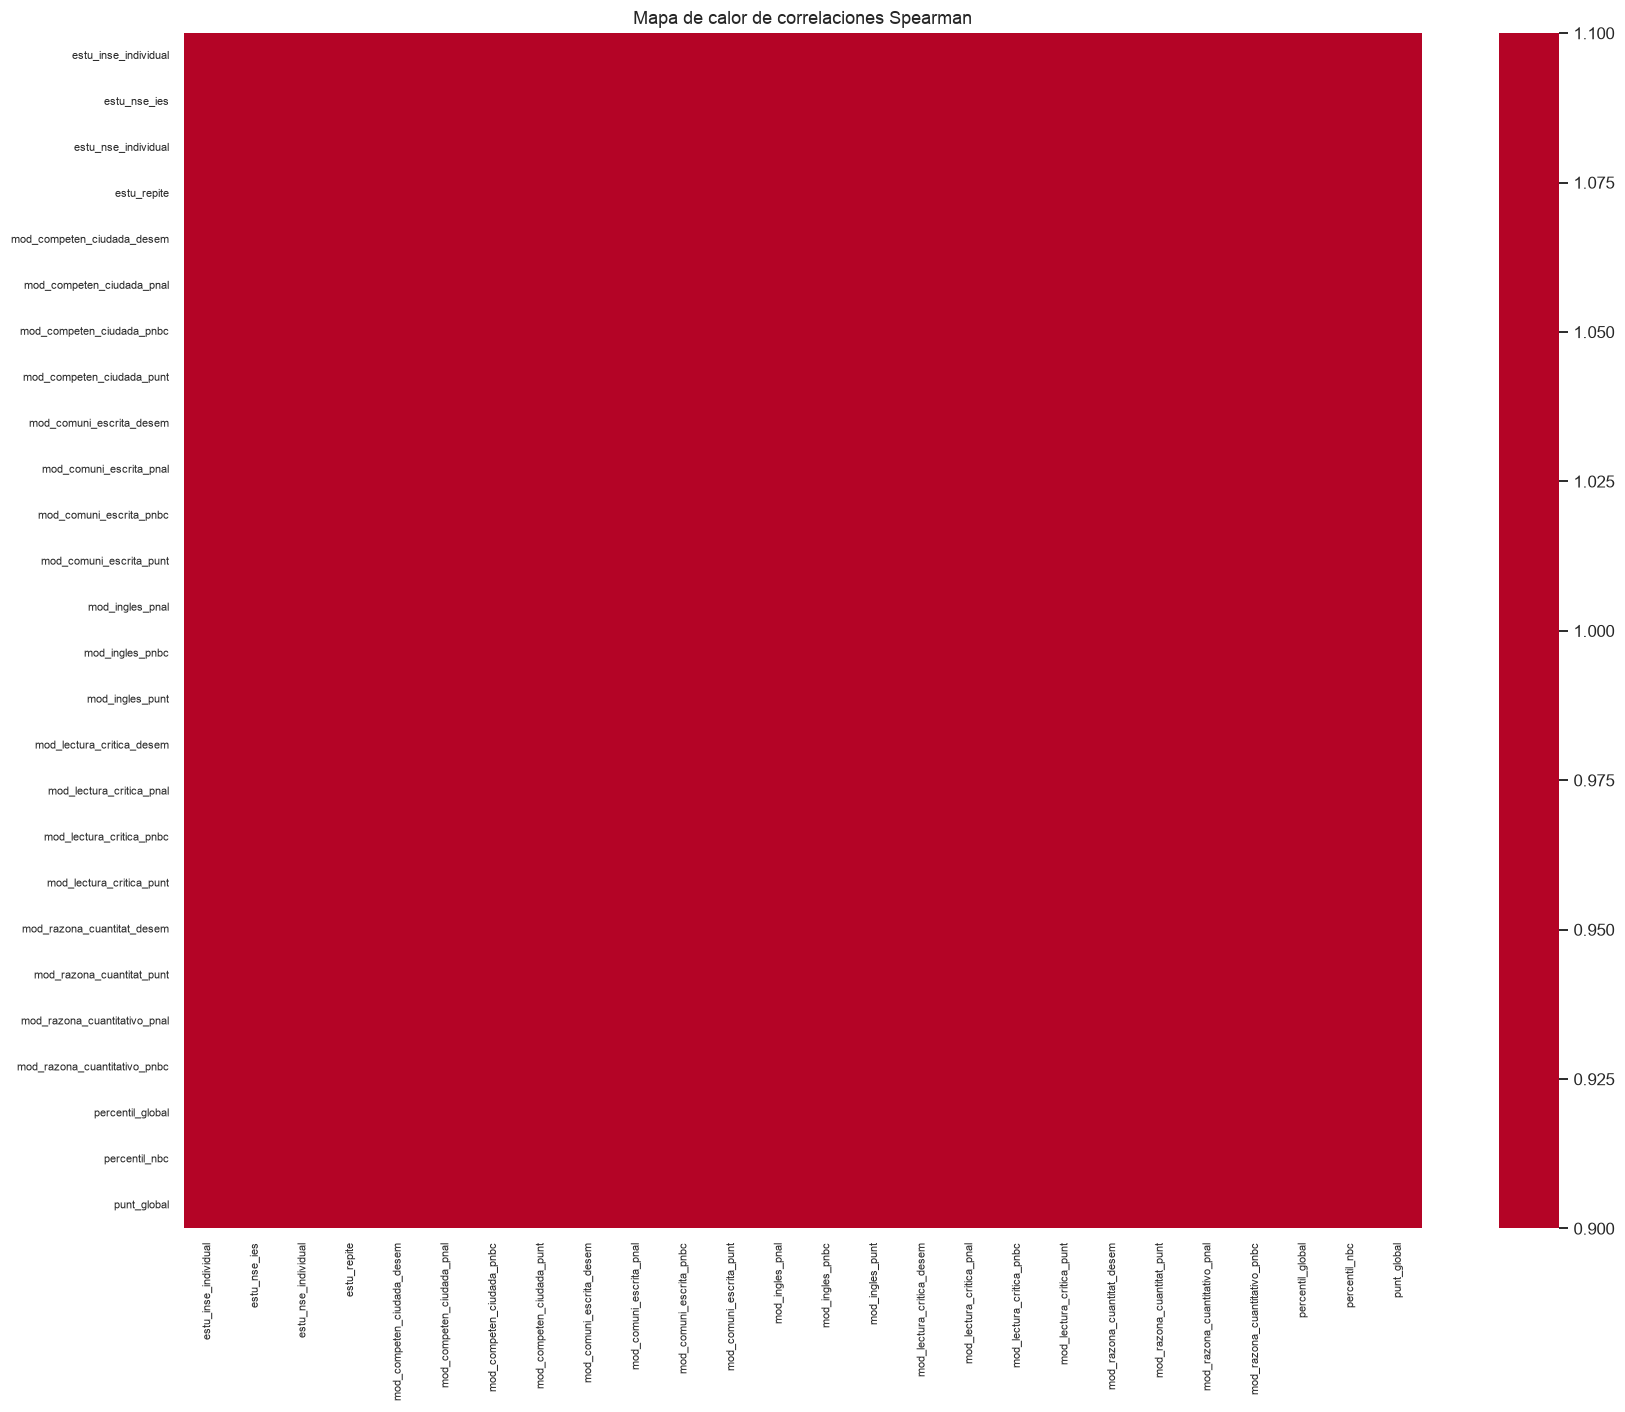

,Pearson,Spearman,correlacion_absoluta_maxima
percentil_global,0.97,1.00,1.00
percentil_nbc,0.91,0.93,0.93
mod_lectura_critica_pnal,0.80,0.82,0.82
mod_lectura_critica_punt,0.81,0.82,0.82
mod_competen_ciudada_pnal,0.78,0.80,0.80
mod_competen_ciudada_punt,0.79,0.80,0.80
mod_lectura_critica_desem,0.76,0.77,0.77
mod_ingles_punt,0.76,0.76,0.76
mod_competen_ciudada_desem,0.74,0.76,0.76
mod_ingles_pnal,0.75,0.76,0.76


In [ ]:
# Correlaciones de Pearson
pearson_correlation = df[numeric_columns].corr(method='pearson')
plt.figure(figsize=(16, 13))
sns.heatmap(pearson_correlation, cmap='coolwarm', center=0, vmin=0, vmax=1)
plt.title('Mapa de calor de correlaciones Pearson')
plt.xticks(rotation=90, fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

# Correlaciones de Spearman
spearman_correlation = df[numeric_columns].corr(method='spearman')
plt.figure(figsize=(16, 13))
sns.heatmap(spearman_correlation, cmap='coolwarm', center=0, vmin=0, vmax=1)
plt.title('Mapa de calor de correlaciones Spearman')
plt.xticks(rotation=90, fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

# Variables más relacionadas con el puntaje global
if 'punt_global' in numeric_columns:
    global_correlations = pd.DataFrame({
        'Pearson': pearson_correlation['punt_global'],
        'Spearman': spearman_correlation['punt_global']
    })
    global_correlations = global_correlations.drop(index='punt_global')
    global_correlations['correlacion_absoluta_maxima'] = global_correlations.abs().max(axis=1)
    display(global_correlations.sort_values('correlacion_absoluta_maxima', ascending=False))

## 8. Relaciones bivariadas exploratorias

Se visualizan las métricas más relacionadas con `punt_global` y su distribución en algunos grupos. Estas son diferencias descriptivas, no efectos causales.

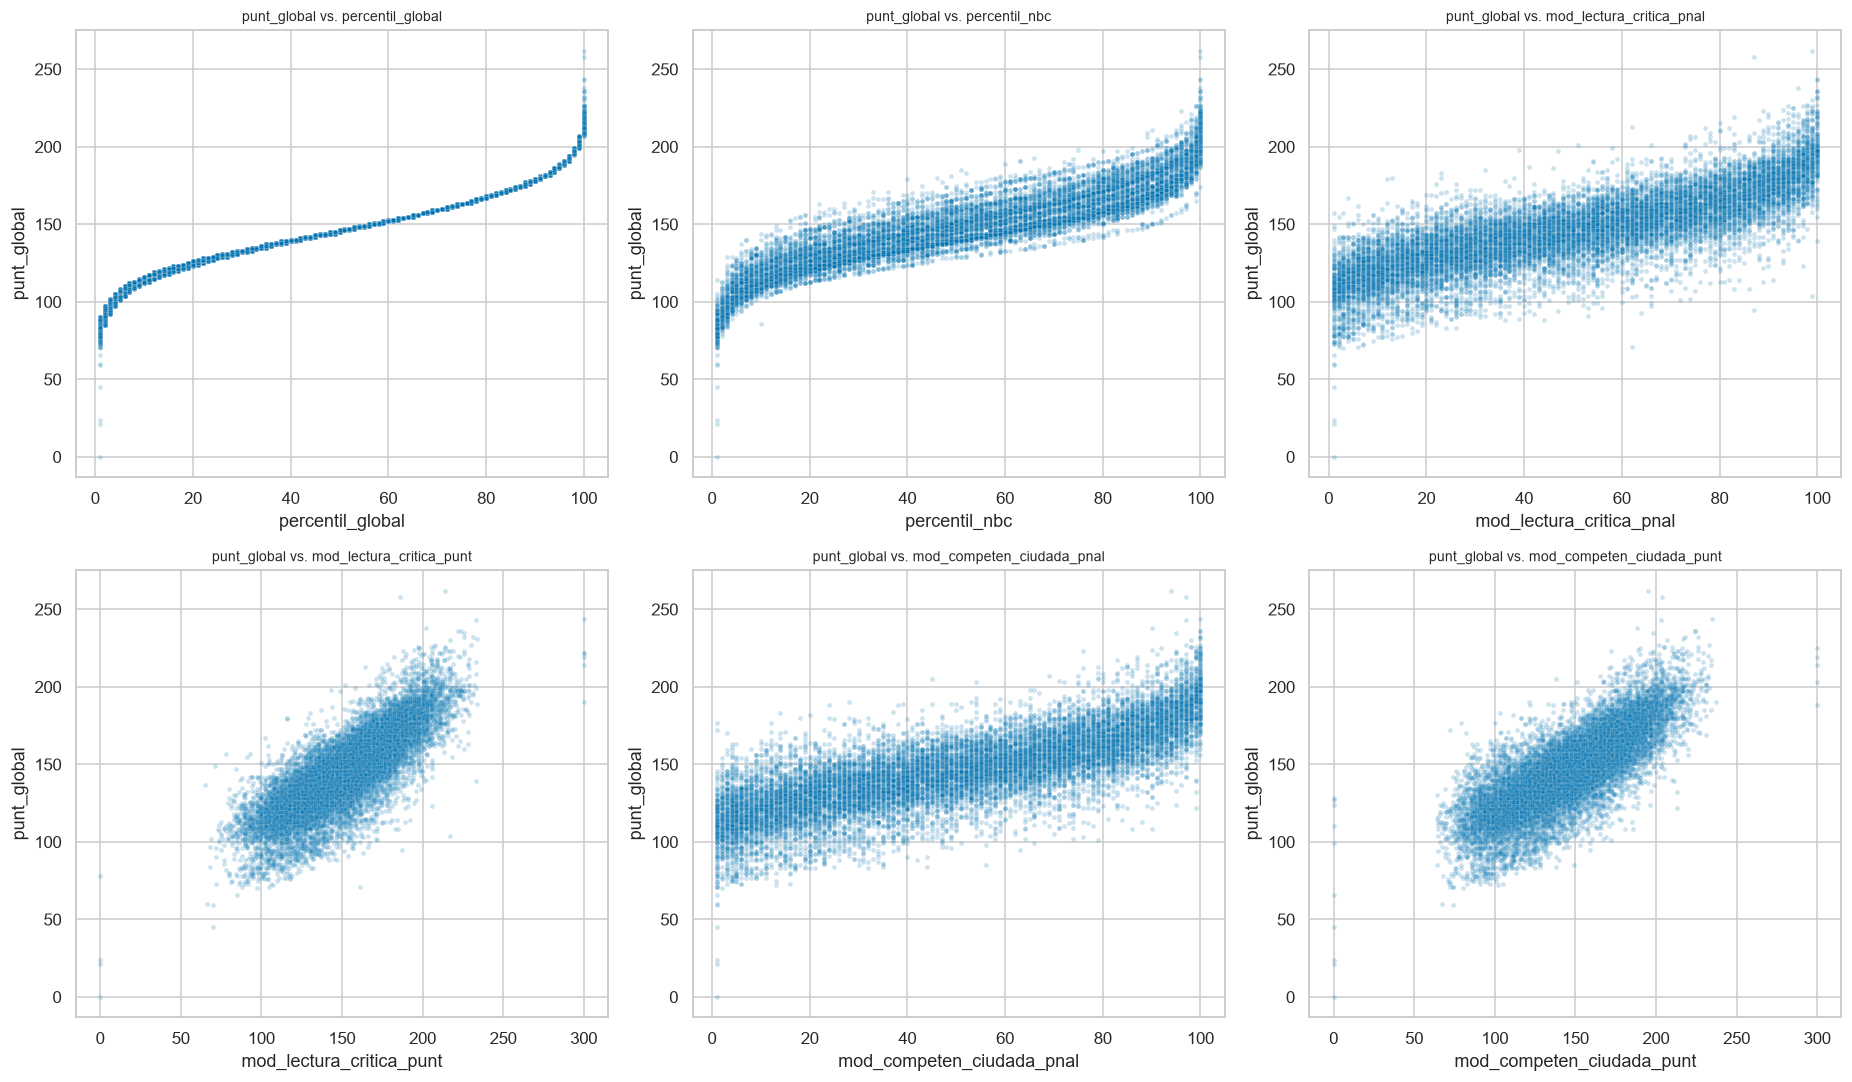

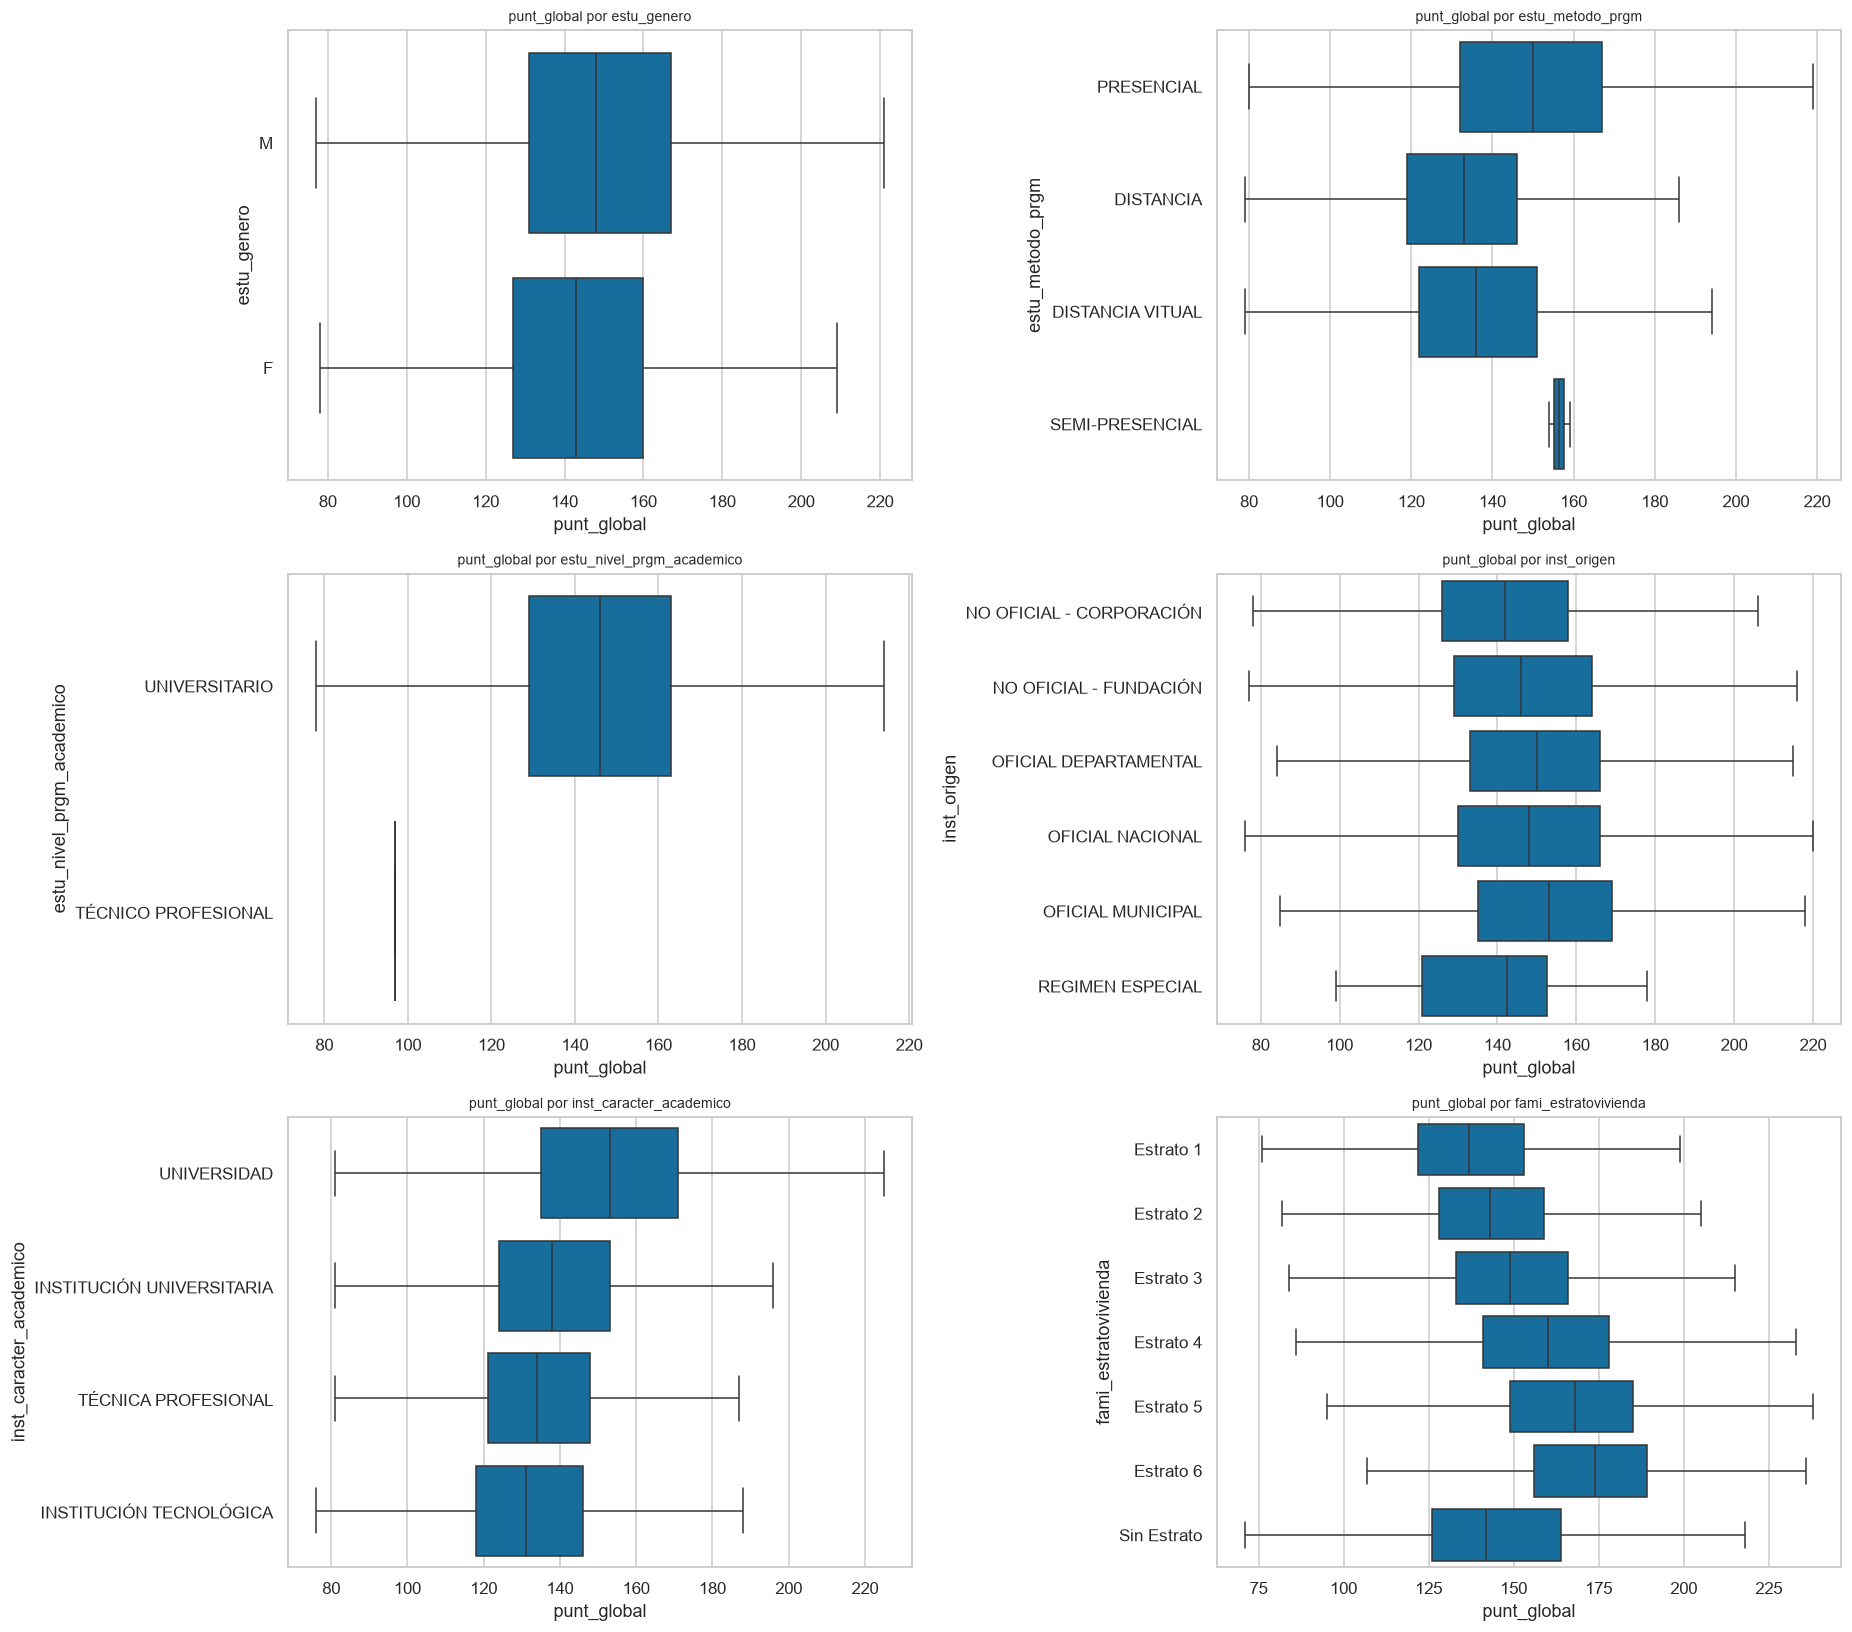

In [ ]:
# Seis métricas con mayor correlación de Spearman con punt_global
correlations_with_global = spearman_correlation['punt_global'].drop('punt_global').abs()
top_six = correlations_with_global.sort_values(ascending=False).head(6).index
scatter_sample = df[list(top_six) + ['punt_global']].sample(min(15_000, len(df)), random_state=RANDOM_STATE)

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.reshape(-1)
for position, column in enumerate(top_six):
    sns.scatterplot(data=scatter_sample, x=column, y='punt_global', alpha=0.2, s=10, ax=axes[position])
    axes[position].set_title(f'punt_global vs. {column}', fontsize=9)
plt.tight_layout()
plt.show()

# Puntaje global por algunos grupos
group_columns = ['estu_genero', 'estu_metodo_prgm', 'estu_nivel_prgm_academico', 'inst_origen', 'inst_caracter_academico', 'fami_estratovivienda']
fig, axes = plt.subplots(3, 2, figsize=(17, 15))
axes = axes.reshape(-1)
for position, column in enumerate(group_columns):
    most_common_groups = df[column].value_counts().head(10).index
    group_data = df[df[column].isin(most_common_groups)][[column, 'punt_global']].dropna()
    if len(group_data) > PLOT_SAMPLE_SIZE:
        group_data = group_data.sample(PLOT_SAMPLE_SIZE, random_state=RANDOM_STATE)
    sns.boxplot(data=group_data, y=column, x='punt_global', showfliers=False, ax=axes[position])
    axes[position].set_title(f'punt_global por {column}', fontsize=9)
plt.tight_layout()
plt.show()

## 9. Resumen de alertas de calidad

Esta tabla reúne señales que merecen revisión posterior. No realiza ninguna corrección.

In [ ]:
quality_summary = pd.DataFrame({
    'Indicador': [
        'Columnas totalmente vacías',
        'Columnas con más de 50% faltante',
        'Columnas constantes',
        'Columnas con cardinalidad mayor a 90%',
        'Filas duplicadas',
        'Filas con identificador duplicado',
        'Variables numéricas con posibles atípicos'
    ],
    'Cantidad': [
        int((schema['faltantes_pct'] == 100).sum()),
        int((schema['faltantes_pct'] > 50).sum()),
        int((schema['valores_unicos'] == 1).sum()),
        int((schema['cardinalidad_pct'] > 90).sum()),
        duplicate_rows,
        duplicate_ids,
        int((outlier_summary['cantidad_atipicos'] > 0).sum())
    ]
})
display(quality_summary)

,Indicador,Cantidad
0,Columnas totalmente vacías,0
1,Columnas con más de 50% faltante,11
2,Columnas constantes,1
3,Columnas con cardinalidad mayor a 90%,1
4,Filas duplicadas,0
5,Filas con identificador duplicado,0
6,Variables numéricas con posibles atípicos,8


## 10. Guía para interpretar los resultados

Al ejecutar el notebook, conviene concentrarse en:

1. El número de estudiantes, instituciones, programas y territorios representados.
2. Las columnas vacías o con muchos faltantes.
3. Las distribuciones muy asimétricas o concentradas.
4. Los posibles atípicos, recordando que no necesariamente son errores.
5. Las correlaciones fuertes y las diferencias entre Pearson y Spearman.
6. Las diferencias descriptivas entre grupos, sin interpretarlas como causalidad.

> Las decisiones de limpieza o preparación deberán justificarse posteriormente. Este notebook no modifica los datos.